## Code for selecting ROIs and analyzing all clusters in this ROI

In [53]:
# %matplotlib qt
# ============================================================
#  BLOCK 1 — Single-ROI cluster shape analysis
#  Select one file, draw one ROI, analyse every DBSCAN cluster.
#  Outputs: per-cluster CSV  +  thesis-quality dashboard figure.
# ============================================================
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
from scipy.ndimage import gaussian_filter
from skimage.measure import find_contours
from shapely.geometry import Polygon as ShapelyPolygon
import tkinter as tk
from tkinter import filedialog
import os
import json
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS  — edit these per experiment
# ============================================================
FILE_PATH  = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B4\10,10,300 control.hdf5"
OUTPUT_DIR = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Shape analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CAMERA_PIXEL_SIZE = 130.0    # nm
NENA_NM           = 10.8     # measured NeNA for THIS file — drives resolution gating
KDE_GRID_RES      = 2.0      # nm per grid pixel (2 nm is plenty below NeNA; keeps it fast)
MIN_LOCS          = 30       # ignore clusters with fewer localisations

# --- Boundary / footprint definition ---
# Footprint contour drawn at this fraction of each cluster's own 99th-pct density.
# Keep constant across all files so areas are comparable.
CONTOUR_FRAC      = 0.30
MIN_CLUSTER_AREA  = 100      # nm^2 — discard contour fragments smaller than this

# --- Radial / hollowness profile ---
RADIAL_BIN_NM     = 5.0

# --- Morphology classifier thresholds (tunable; validated on synthetic shapes) ---
ELONGATED_LINEARITY = 0.45   # linearity above this  -> Elongated / filament
HOLLOW_CORE_RATIO   = 0.50   # core/peak density below this -> candidate ring
RING_MIN_RG         = 2.0 * NENA_NM   # cluster must be big enough (Rg) for a void to be resolvable

# ============================================================
# 2. THESIS PLOT STYLE
# ============================================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.linewidth': 0.6,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
    'legend.fontsize': 7, 'legend.frameon': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300,
})
CLASS_COLORS = {'Compact': '#4C72B0', 'Elongated': '#DD8452',
                'Ring-like': '#55A868', 'Unclassified': '#BBBBBB'}

# ============================================================
# 3. METRIC ENGINE  (validated to discriminate disk/ring/filament/square)
# ============================================================
def compute_metrics(pts):
    """pts: (N,2) array in nm. Returns dict of shape descriptors."""
    out = {}
    n = len(pts)
    out['N_Localizations'] = n
    c = pts.mean(axis=0)
    p = pts - c

    # --- PCA (rotation-invariant elongation) ---
    evals = np.sort(np.linalg.eigvalsh(np.cov(p.T)))[::-1]
    l1, l2 = evals[0], max(evals[1], 1e-9)
    out['Rg_nm']        = np.sqrt((p**2).sum() / n)        # radius of gyration, threshold-free
    out['Aspect_Ratio'] = np.sqrt(l1 / l2)                 # 1 = round
    out['Eccentricity'] = np.sqrt(max(0.0, 1 - l2 / l1))   # 0 = round, ->1 = line
    out['Linearity']    = (l1 - l2) / (l1 + l2)            # 0 = isotropic, 1 = line

    # --- KDE footprint contour (shapely) ---
    pad = 3 * NENA_NM
    xmn, xmx = pts[:, 0].min() - pad, pts[:, 0].max() + pad
    ymn, ymx = pts[:, 1].min() - pad, pts[:, 1].max() + pad
    bx = max(8, int((xmx - xmn) / KDE_GRID_RES))
    by = max(8, int((ymx - ymn) / KDE_GRID_RES))
    H, xe, ye = np.histogram2d(pts[:, 0], pts[:, 1], bins=(bx, by),
                               range=[[xmn, xmx], [ymn, ymx]])
    dens = gaussian_filter(H, sigma=NENA_NM / KDE_GRID_RES)
    active = dens[dens > 0]
    if active.size == 0:
        return None
    thresh = np.percentile(active, 99) * CONTOUR_FRAC
    contours = find_contours(dens, thresh)

    polys = []
    for ct in contours:
        xx = xe[0] + ct[:, 0] * KDE_GRID_RES
        yy = ye[0] + ct[:, 1] * KDE_GRID_RES
        if len(ct) >= 4:
            sp = ShapelyPolygon(np.column_stack([xx, yy]))
            if sp.is_valid and sp.area > MIN_CLUSTER_AREA:
                polys.append(sp)
    if not polys:
        return None
    main = max(polys, key=lambda s: s.area)

    out['Area_nm2']      = main.area
    out['Perimeter_nm']  = main.length
    conv = main.convex_hull
    out['Convex_Area_nm2'] = conv.area
    out['Solidity']      = main.area / conv.area if conv.area > 0 else np.nan
    out['Circularity']   = 4 * np.pi * main.area / main.length**2 if main.length > 0 else np.nan
    mrr = main.minimum_rotated_rectangle
    out['Rectangularity'] = main.area / mrr.area if mrr.area > 0 else np.nan  # origami QC only

    # --- Radial density profile -> hollowness ---
    d = np.linalg.norm(p, axis=1)
    edges = np.arange(0, d.max() + RADIAL_BIN_NM, RADIAL_BIN_NM)
    if len(edges) < 3:
        out['Peak_Radius_nm'] = 0.0
        out['Core_Ratio']     = 1.0
        out['Radial_Profile'] = ""
        out['_radial'] = None
    else:
        rmid = (edges[:-1] + edges[1:]) / 2
        ring_area = np.pi * (edges[1:]**2 - edges[:-1]**2)
        cnt, _ = np.histogram(d, bins=edges)
        rd = cnt / ring_area
        rd_s = gaussian_filter(rd, sigma=1.0)          # light smoothing
        peak_r = rmid[np.argmax(rd_s)]
        core_mask = rmid < max(peak_r * 0.5, NENA_NM)
        core = rd_s[core_mask].mean() if core_mask.any() else rd_s[0]
        norm_prof = rd_s / rd_s.max() if rd_s.max() > 0 else rd_s
        out['Peak_Radius_nm'] = peak_r
        out['Core_Ratio']     = core / rd_s.max() if rd_s.max() > 0 else 1.0
        # persist the profile (radial bins start at RADIAL_BIN_NM/2, step RADIAL_BIN_NM)
        out['Radial_Profile'] = json.dumps([round(float(v), 4) for v in norm_prof])
        out['_radial'] = (rmid, norm_prof)             # normalised profile for plotting

    out['_centroid'] = c
    out['_boundary'] = np.array(main.exterior.coords)
    return out


def classify(m):
    if m['Linearity'] > ELONGATED_LINEARITY:
        return 'Elongated'
    if (m['Core_Ratio'] < HOLLOW_CORE_RATIO) and (m['Rg_nm'] > RING_MIN_RG):
        return 'Ring-like'
    return 'Compact'

# ============================================================
# 4. LOAD + INTERACTIVE ROI
# ============================================================
print("Loading HDF5 ...")
with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]
locs = locs[locs['group'] >= 0]
x_nm, y_nm = locs['x'] * CAMERA_PIXEL_SIZE, locs['y'] * CAMERA_PIXEL_SIZE
groups = locs['group']

print("Draw ROI around ONE cell. Close the window when done.")
fig_roi, ax_roi = plt.subplots(figsize=(8, 8))
ax_roi.scatter(x_nm, y_nm, s=1, alpha=0.12, color='#333333', rasterized=True)
ax_roi.invert_yaxis(); ax_roi.set_aspect('equal')
ax_roi.set_title("Draw ROI around one cell, then close")
poly_verts = []
def onselect(v):
    global poly_verts; poly_verts = v
selector = PolygonSelector(ax_roi, onselect, props=dict(color='crimson', linewidth=1.0))
plt.show(block=True)
if not poly_verts:
    raise ValueError("No ROI selected.")

# --- metadata prompts ---
condition = input("Condition (Control / Apoptosis / Pyroptosis / Origami): ").strip() or "Unknown"
cell_id   = input("Cell / ROI id (e.g. Cell_1): ").strip() or "Cell_1"
save_name = f"{condition}_{cell_id}"

# ROI area (shoelace) for cluster-density
xp, yp = zip(*poly_verts)
roi_area_nm2 = 0.5 * np.abs(np.dot(xp, np.roll(yp, 1)) - np.dot(yp, np.roll(xp, 1)))
roi_area_um2 = roi_area_nm2 / 1e6

mask = Path(poly_verts).contains_points(np.vstack((x_nm, y_nm)).T)
df_roi = pd.DataFrame({'x': x_nm[mask], 'y': y_nm[mask], 'group': groups[mask]})

# ============================================================
# 5. ANALYSE EVERY CLUSTER
# ============================================================
print("Analysing clusters ...")
rows, profiles = [], []

# Representative example per class, for the visual morphology key.
# Score picks the clearest archetype; we prefer well-populated clusters.
NICE_N = 100
def example_score(cls, m):
    if cls == 'Compact':    return m['Core_Ratio'] - m['Eccentricity']   # round + solid
    if cls == 'Elongated':  return m['Linearity']                        # most linear
    return -m['Core_Ratio']                                              # Ring-like: most hollow
ex_nice, ex_any = {}, {}   # cls -> (score, pts)

for cid, g in df_roi.groupby('group'):
    pts = g[['x', 'y']].values
    if len(pts) < MIN_LOCS:
        continue
    m = compute_metrics(pts)
    if m is None:
        continue
    cls = classify(m)
    m['Morphology'] = cls
    if m['_radial'] is not None:
        profiles.append(m['_radial'])
    # track representative example
    sc = example_score(cls, m)
    if (cls not in ex_any) or (sc > ex_any[cls][0]):
        ex_any[cls] = (sc, pts)
    if len(pts) >= NICE_N and ((cls not in ex_nice) or (sc > ex_nice[cls][0])):
        ex_nice[cls] = (sc, pts)
    row = {k: v for k, v in m.items() if not k.startswith('_')}
    row.update({'Cluster_ID': cid, 'Condition': condition, 'Cell_ID': cell_id})
    rows.append(row)

if not rows:
    raise RuntimeError("No clusters passed the filters in this ROI.")

df = pd.DataFrame(rows)
csv_path = os.path.join(OUTPUT_DIR, f"{save_name}_clusters.csv")
df.to_csv(csv_path, index=False)
print(f"Saved per-cluster table -> {csv_path}")

# Resolve final example per class (prefer well-populated), subsample, and save
# a companion file so the cumulative figure (Block 2) can show real examples too.
examples = {}
for cls in ['Compact', 'Elongated', 'Ring-like']:
    chosen = ex_nice.get(cls, ex_any.get(cls))
    if chosen is None:
        continue
    pts = chosen[1]
    if len(pts) > 400:
        idx = np.random.default_rng(0).choice(len(pts), 400, replace=False)
        pts = pts[idx]
    examples[cls] = {'score': float(chosen[0]),
                     'pts': (pts - pts.mean(axis=0)).round(1).tolist()}
with open(os.path.join(OUTPUT_DIR, f"{save_name}_examples.json"), 'w') as fh:
    json.dump(examples, fh)

# ============================================================
# 6. THESIS DASHBOARD  (2 x 3)
#   Row 0:  Morphology KEY (real example clusters) | Size vs shape | Hollowness map
#   Row 1:  Radial profile | Footprint area        | Morphology class mix
#   The key comes first so the reader learns what each colour IS before it is used.
# ============================================================
n_total = len(df)
density_um2 = n_total / roi_area_um2 if roi_area_um2 > 0 else 0
class_counts = df['Morphology'].value_counts()
class_order = ['Compact', 'Elongated', 'Ring-like']

fig = plt.figure(figsize=(12, 7))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.36, wspace=0.30,
                       left=0.06, right=0.97, top=0.88, bottom=0.11)

fig.suptitle(f"{condition}  ·  {cell_id}    |    {n_total} clusters in "
             f"{roi_area_um2:.1f} µm²   ({density_um2:.2f} clusters/µm²)",
             fontsize=13, fontweight='bold', y=0.965)

# --- A: MORPHOLOGY KEY — one representative real cluster per class ---
axk = fig.add_subplot(gs[0, 0]); axk.axis('off'); axk.set_aspect('equal')
axk.set_title("Morphology key — example clusters", fontsize=9, fontweight='bold')
present_ex = [c for c in class_order if examples.get(c) is not None]
gr = (max(np.abs(np.asarray(examples[c]['pts'], float)).max() for c in present_ex) * 1.12
      if present_ex else 1.0)
s = 0.40 / gr
for i, cls in enumerate(class_order):
    cx = i * 1.0
    axk.text(cx, -0.58, cls, ha='center', va='top',
             color=CLASS_COLORS[cls], fontsize=8.5, fontweight='bold')
    ex = examples.get(cls)
    if ex is None:
        axk.text(cx, 0, "(none\nfound)", ha='center', va='center',
                 color='#aaaaaa', fontsize=7)
        continue
    p = np.asarray(ex['pts'], float)
    axk.scatter(cx + p[:, 0] * s, p[:, 1] * s, s=2, color=CLASS_COLORS[cls],
                alpha=0.75, edgecolors='none')
axk.plot([-0.40, -0.40 + 50 * s], [-0.50, -0.50], color='k', lw=1.5)
axk.text(-0.40 + 25 * s, -0.54, '50 nm', ha='center', va='top', fontsize=6)
axk.set_xlim(-0.6, (len(class_order) - 1) + 0.6)
axk.set_ylim(-0.78, 0.52)

# --- B: size vs shape (with the Elongated decision boundary drawn on the data) ---
ax = fig.add_subplot(gs[0, 1])
for cls in class_order:
    sub = df[df['Morphology'] == cls]
    if len(sub):
        ax.scatter(sub['Rg_nm'], sub['Eccentricity'], s=20, alpha=0.75,
                   color=CLASS_COLORS[cls], edgecolors='k', linewidths=0.2)
ecc_elong = np.sqrt(2 * ELONGATED_LINEARITY / (1 + ELONGATED_LINEARITY))
ax.axhline(ecc_elong, color='#777777', ls='--', lw=0.8)
ax.text(0.98, ecc_elong + 0.015, "Elongated ↑",
        transform=ax.get_yaxis_transform(), ha='right', va='bottom',
        fontsize=6.5, color='#777777', style='italic')
ax.set_title("Size vs shape")
ax.set_xlabel("Radius of gyration (nm)"); ax.set_ylabel("Eccentricity  (0 = round)")
ax.set_ylim(-0.02, 1.0)

# --- C: hollowness map (gates shaded) with a plain colour legend ---
ax = fig.add_subplot(gs[0, 2])
rg_max = max(df['Rg_nm'].max() * 1.05, RING_MIN_RG * 1.5)
ax.axvspan(0, RING_MIN_RG, color='grey', alpha=0.14)
ax.axhspan(HOLLOW_CORE_RATIO, 1.25, color='grey', alpha=0.14)
for cls in class_order:
    sub = df[df['Morphology'] == cls]
    if len(sub):
        ax.scatter(sub['Rg_nm'], sub['Core_Ratio'], s=20, alpha=0.75,
                   color=CLASS_COLORS[cls], edgecolors='k', linewidths=0.2, label=cls)
ax.set_xlim(0, rg_max); ax.set_ylim(0, 1.25)
ax.set_title("Hollowness map")
ax.set_xlabel("Radius of gyration (nm)"); ax.set_ylabel("Core ratio  (low = hollow)")
ax.legend(loc='lower right', fontsize=6.5, frameon=True, framealpha=0.85,
          edgecolor='#cccccc', markerscale=1.3)

# --- D: mean radial density profile ---
ax = fig.add_subplot(gs[1, 0])
if profiles:
    maxlen = max(len(r[0]) for r in profiles)
    grid = np.arange(maxlen) * RADIAL_BIN_NM + RADIAL_BIN_NM / 2
    stack = np.full((len(profiles), maxlen), np.nan)
    for i, (rmid, prof) in enumerate(profiles):
        stack[i, :len(prof)] = prof
        ax.plot(rmid, prof, color='grey', alpha=0.06, lw=0.6)
    ax.plot(grid, np.nanmean(stack, axis=0), color='black', lw=2.2, label='Mean')
    ax.axvspan(0, NENA_NM, color='red', alpha=0.10)
    ax.legend(fontsize=7, loc='upper right')
ax.set_title("Radial density profile")
ax.set_xlabel("Radius from centroid (nm)"); ax.set_ylabel("Normalised density")

# --- E: footprint area ---
ax = fig.add_subplot(gs[1, 1])
ax.hist(df['Area_nm2'], bins=22, color='#4C72B0', edgecolor='white', linewidth=0.4)
med = df['Area_nm2'].median()
ax.axvline(med, color='crimson', ls='--', lw=1.2, label=f"median {med:.0f} nm²")
ax.set_title("Footprint area")
ax.set_xlabel("Area (nm²)"); ax.set_ylabel("Count")
ax.legend(fontsize=7)

# --- F: morphology class mix ---
ax = fig.add_subplot(gs[1, 2])
counts = [class_counts.get(k, 0) for k in class_order]
bars = ax.bar(class_order, counts, color=[CLASS_COLORS[k] for k in class_order],
              edgecolor='black', linewidth=0.5)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c, f"{100*c/n_total:.0f}%",
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title("Morphology class mix")
ax.set_ylabel("Count")
ax.set_ylim(0, max(counts) * 1.18 if counts else 1)

# factual footer (method parameters only)
fig.text(0.5, 0.02,
         f"NeNA = {NENA_NM:.1f} nm   ·   ring detection limited to Rg ≳ {RING_MIN_RG:.0f} nm   "
         f"·   grey bands mark unresolvable / non-hollow regions",
         ha='center', va='bottom', fontsize=6.5, color='#666666')

for a in fig.axes:
    for sp in ['top', 'right']:
        if sp in a.spines:
            a.spines[sp].set_visible(False)

fig_path = os.path.join(OUTPUT_DIR, f"{save_name}_dashboard.pdf")
fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved dashboard -> {fig_path}")
plt.show()

Loading HDF5 ...
Draw ROI around ONE cell. Close the window when done.


Condition (Control / Apoptosis / Pyroptosis / Origami):  Control
Cell / ROI id (e.g. Cell_1):  cell3


Analysing clusters ...
Saved per-cluster table -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Shape analysis\Control_cell3_clusters.csv
Saved dashboard -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Shape analysis\Control_cell3_dashboard.pdf


## Code for aggregating cell by cell results

In [77]:
# %matplotlib inline
# ============================================================
#  BLOCK 2 — Cumulative shape analysis (one condition, many cells)
#  Select all the per-ROI cluster CSVs from Block 1 for ONE condition.
#  Produces the SAME 6-panel dashboard as Block 1, pooled across cells.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tkinter as tk
from tkinter import filedialog
import os
import json

# ============================================================
# 1. SETTINGS
# ============================================================
OUTPUT_DIR = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Cumulative"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_LOCS = 6000
MAX_AREA = None

# --- These MUST match Block 1 (used to recompute Morphology for old CSVs) ---
NENA_NM             = 10.8
ELONGATED_LINEARITY = 0.45
HOLLOW_CORE_RATIO   = 0.50
RING_MIN_RG         = 2.0 * NENA_NM
RADIAL_BIN_NM       = 5.0

CLASS_COLORS = {'Compact': '#4C72B0', 'Elongated': '#DD8452', 'Ring-like': '#55A868'}
CLASS_ORDER  = ['Compact', 'Elongated', 'Ring-like']
METRICS = ['Area_nm2', 'Rg_nm', 'Eccentricity', 'Core_Ratio', 'Solidity', 'N_Localizations']

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.linewidth': 0.6, 'axes.titlesize': 9,
    'axes.titleweight': 'bold', 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'legend.frameon': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 300,
})

def classify_row(r):
    if r.get('Linearity', 0) > ELONGATED_LINEARITY:
        return 'Elongated'
    if (r.get('Core_Ratio', 1) < HOLLOW_CORE_RATIO) and (r.get('Rg_nm', 0) > RING_MIN_RG):
        return 'Ring-like'
    return 'Compact'

# ============================================================
# 2. SELECT FILES + LOAD (+ representative examples saved by Block 1)
# ============================================================
root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
print("Select all per-ROI cluster CSVs for ONE condition.")
files = filedialog.askopenfilenames(title="Select cluster CSVs (one condition)",
                                     filetypes=[("CSV", "*.csv")])
root.destroy()
if not files:
    raise ValueError("No files selected.")

frames, examples = [], {}
for f in files:
    d = pd.read_csv(f)
    if 'Cell_ID' not in d.columns:
        d['Cell_ID'] = os.path.splitext(os.path.basename(f))[0]
    frames.append(d)
    # companion examples file written by Block 1
    ej = f[:-len('_clusters.csv')] + '_examples.json' if f.endswith('_clusters.csv') \
        else os.path.splitext(f)[0] + '_examples.json'
    if os.path.exists(ej):
        try:
            for cls, info in json.load(open(ej)).items():
                if cls not in examples or info.get('score', -1e9) > examples[cls]['score']:
                    examples[cls] = info
        except (ValueError, KeyError):
            pass
df = pd.concat(frames, ignore_index=True)

condition = (str(df['Condition'].iloc[0]) if 'Condition' in df.columns
             else os.path.basename(files[0]).split('_')[0])

if 'Morphology' not in df.columns or df['Morphology'].isna().any():
    if {'Linearity', 'Core_Ratio', 'Rg_nm'}.issubset(df.columns):
        df['Morphology'] = df.apply(classify_row, axis=1)

# ============================================================
# 3. QUALITY CONTROL
# ============================================================
n0 = len(df)
if MAX_LOCS is not None and 'N_Localizations' in df.columns:
    df = df[df['N_Localizations'] <= MAX_LOCS]
if MAX_AREA is not None and 'Area_nm2' in df.columns:
    df = df[df['Area_nm2'] <= MAX_AREA]
cells = sorted(df['Cell_ID'].unique())
print(f"Pooled {n0} clusters, {len(df)} kept after QC, from {len(cells)} cell(s).")

# ============================================================
# 4. SAVE POOLED + PER-CELL TABLES
# ============================================================
pooled_path = os.path.join(OUTPUT_DIR, f"{condition}_pooled_clusters.csv")
df.to_csv(pooled_path, index=False)

metrics_present = [m for m in METRICS if m in df.columns]
percell = df.groupby('Cell_ID')[metrics_present].median()
percell.columns = [f"median_{c}" for c in percell.columns]
percell['n_clusters'] = df.groupby('Cell_ID').size()
cls_counts = (df.groupby('Cell_ID')['Morphology'].value_counts()
                .unstack(fill_value=0).reindex(columns=CLASS_ORDER, fill_value=0))
cls_frac = cls_counts.div(cls_counts.sum(axis=1), axis=0)
for c in CLASS_ORDER:
    percell[f"n_{c}"] = cls_counts[c]
    percell[f"frac_{c}"] = cls_frac[c]
percell['Condition'] = condition
percell = percell.reset_index()
percell_path = os.path.join(OUTPUT_DIR, f"{condition}_per_cell_summary.csv")
percell.to_csv(percell_path, index=False)
print(f"Saved pooled table   -> {pooled_path}")
print(f"Saved per-cell means -> {percell_path}")

# ============================================================
# 5. CUMULATIVE DASHBOARD  (same 6 panels as Block 1)
#   Row 0:  Morphology KEY | Size vs shape | Hollowness map
#   Row 1:  Radial profile | Footprint area | Morphology class mix
# ============================================================
n_total = len(df)
class_counts = df['Morphology'].value_counts()

fig = plt.figure(figsize=(12, 7))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.36, wspace=0.30,
                       left=0.06, right=0.97, top=0.88, bottom=0.11)
fig.suptitle(f"{condition}  ·  cumulative    |    {n_total} clusters pooled "
             f"from {len(cells)} cell(s)",
             fontsize=13, fontweight='bold', y=0.965)

# --- A: MORPHOLOGY KEY (real examples only; classes with none are left blank) ---
axk = fig.add_subplot(gs[0, 0]); axk.axis('off'); axk.set_aspect('equal')
axk.set_title("Morphology key — example clusters", fontsize=9, fontweight='bold')
present_ex = [c for c in CLASS_ORDER if c in examples]
gr = (max(np.abs(np.asarray(examples[c]['pts'], float)).max() for c in present_ex) * 1.12
      if present_ex else 1.0)
s = 0.40 / gr
for i, cls in enumerate(CLASS_ORDER):
    cx = i * 1.0
    axk.text(cx, -0.58, cls, ha='center', va='top',
             color=CLASS_COLORS[cls], fontsize=8.5, fontweight='bold')
    if cls not in examples:
        axk.text(cx, 0, "(no example\nin data)", ha='center', va='center',
                 color='#aaaaaa', fontsize=6.5)
        continue
    p = np.asarray(examples[cls]['pts'], float)
    axk.scatter(cx + p[:, 0] * s, p[:, 1] * s, s=2, color=CLASS_COLORS[cls],
                alpha=0.75, edgecolors='none')
axk.plot([-0.40, -0.40 + 50 * s], [-0.50, -0.50], color='k', lw=1.5)
axk.text(-0.40 + 25 * s, -0.54, '50 nm', ha='center', va='top', fontsize=6)
axk.set_xlim(-0.6, (len(CLASS_ORDER) - 1) + 0.6); axk.set_ylim(-0.82, 0.52)

# --- B: size vs shape (with Elongated boundary) ---
ax = fig.add_subplot(gs[0, 1])
for cls in CLASS_ORDER:
    sub = df[df['Morphology'] == cls]
    if len(sub):
        ax.scatter(sub['Rg_nm'], sub['Eccentricity'], s=14, alpha=0.55,
                   color=CLASS_COLORS[cls], edgecolors='k', linewidths=0.15)
ecc_elong = np.sqrt(2 * ELONGATED_LINEARITY / (1 + ELONGATED_LINEARITY))
ax.axhline(ecc_elong, color='#777777', ls='--', lw=0.8)
ax.text(0.98, ecc_elong + 0.015, "Elongated ↑",
        transform=ax.get_yaxis_transform(), ha='right', va='bottom',
        fontsize=6.5, color='#777777', style='italic')
ax.set_title("Size vs shape")
ax.set_xlabel("Radius of gyration (nm)"); ax.set_ylabel("Eccentricity  (0 = round)")
ax.set_ylim(-0.02, 1.0)

# --- C: hollowness map (gates shaded) + colour legend ---
ax = fig.add_subplot(gs[0, 2])
rg_max = max(df['Rg_nm'].max() * 1.05, RING_MIN_RG * 1.5)
ax.axvspan(0, RING_MIN_RG, color='grey', alpha=0.14)
ax.axhspan(HOLLOW_CORE_RATIO, 1.25, color='grey', alpha=0.14)
for cls in CLASS_ORDER:
    sub = df[df['Morphology'] == cls]
    if len(sub):
        ax.scatter(sub['Rg_nm'], sub['Core_Ratio'], s=14, alpha=0.55,
                   color=CLASS_COLORS[cls], edgecolors='k', linewidths=0.15, label=cls)
ax.set_xlim(0, rg_max); ax.set_ylim(0, 1.25)
ax.set_title("Hollowness map")
ax.set_xlabel("Radius of gyration (nm)"); ax.set_ylabel("Core ratio  (low = hollow)")
ax.legend(loc='lower right', fontsize=6.5, frameon=True, framealpha=0.85,
          edgecolor='#cccccc', markerscale=1.3)

# --- D: cumulative radial density profile ---
ax = fig.add_subplot(gs[1, 0])
profs = []
if 'Radial_Profile' in df.columns:
    for sv in df['Radial_Profile'].dropna():
        try:
            arr = json.loads(sv) if isinstance(sv, str) else sv
            if isinstance(arr, list) and len(arr):
                profs.append(np.asarray(arr, dtype=float))
        except (ValueError, TypeError):
            continue
if profs:
    L = max(len(p) for p in profs)
    grid = (np.arange(L) + 0.5) * RADIAL_BIN_NM
    M = np.full((len(profs), L), np.nan)
    for i, p in enumerate(profs):
        M[i, :len(p)] = p
    if len(profs) <= 200:
        for p in profs:
            ax.plot(grid[:len(p)], p, color='grey', alpha=0.05, lw=0.6)
    else:
        ax.fill_between(grid, np.nanpercentile(M, 25, axis=0),
                        np.nanpercentile(M, 75, axis=0), color='grey', alpha=0.25, label='IQR')
    ax.plot(grid, np.nanmean(M, axis=0), color='black', lw=2.2, label='Mean')
    ax.axvspan(0, NENA_NM, color='red', alpha=0.10)
    ax.legend(fontsize=7, loc='upper right')
else:
    ax.text(0.5, 0.5, "No radial profiles in these CSVs.\nRe-run Block 1 to populate.",
            ha='center', va='center', fontsize=7.5, color='#888888', transform=ax.transAxes)
ax.set_title("Radial density profile")
ax.set_xlabel("Radius from centroid (nm)"); ax.set_ylabel("Normalised density")

# --- E: footprint area ---
ax = fig.add_subplot(gs[1, 1])
ax.hist(df['Area_nm2'], bins=30, color='#4C72B0', edgecolor='white', linewidth=0.4)
med = df['Area_nm2'].median()
ax.axvline(med, color='crimson', ls='--', lw=1.2, label=f"median {med:.0f} nm²")
ax.set_title("Footprint area"); ax.set_xlabel("Area (nm²)"); ax.set_ylabel("Count")
ax.legend(fontsize=7)

# --- F: morphology class mix (pooled) ---
ax = fig.add_subplot(gs[1, 2])
counts = [class_counts.get(k, 0) for k in CLASS_ORDER]
bars = ax.bar(CLASS_ORDER, counts, color=[CLASS_COLORS[k] for k in CLASS_ORDER],
              edgecolor='black', linewidth=0.5)
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c, f"{100*c/n_total:.0f}%",
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title("Morphology class mix"); ax.set_ylabel("Count")
ax.set_ylim(0, max(counts) * 1.18 if counts else 1)

fig.text(0.5, 0.02,
         f"{len(cells)} cells pooled   ·   NeNA = {NENA_NM:.1f} nm   "
         f"·   ring detection limited to Rg ≳ {RING_MIN_RG:.0f} nm   "
         f"·   grey bands mark unresolvable / non-hollow regions",
         ha='center', va='bottom', fontsize=6.5, color='#666666')

for a in fig.axes:
    for sp in ['top', 'right']:
        if sp in a.spines:
            a.spines[sp].set_visible(False)

fig_path = os.path.join(OUTPUT_DIR, f"{condition}_cumulative_dashboard.pdf")
fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved dashboard -> {fig_path}")
plt.show()

Select all per-ROI cluster CSVs for ONE condition.
Pooled 3435 clusters, 3432 kept after QC, from 1 cell(s).
Saved pooled table   -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Cumulative\Origami_pooled_clusters.csv
Saved per-cell means -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Cumulative\Origami_per_cell_summary.csv
Saved dashboard -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Cumulative\Origami_cumulative_dashboard.pdf


 ## Code for comparing cluster results by pathways

In [87]:
# %matplotlib inline
# ============================================================
#  BLOCK 3 — Compare conditions (Control / Apoptosis / Pyroptosis / Origami)
#  Select ALL the cumulative "*_pooled_clusters.csv" files at once.
#  Produces EVERY pairwise comparison + an all-conditions overview,
#  each saved as its own figure + stats CSV. Everything stored in OUTPUT_DIR.
#  Effect size (Cliff's delta) is the headline result and gets its own panel.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency
import tkinter as tk
from tkinter import filedialog
import os
import itertools

# ============================================================
# 1. SETTINGS
# ============================================================
OUTPUT_DIR = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Comparison"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Statistical unit: 'cluster' (every cluster) or 'cell' (one median per cell).
# Cluster-level gives huge N and tiny p-values -> judge differences by Cliff's delta.
STAT_UNIT = 'cluster'

METRICS = ['Area_nm2', 'Rg_nm', 'Eccentricity', 'Core_Ratio']
LABELS  = ['Footprint area (nm²)', 'Radius of gyration (nm)',
           'Eccentricity (elongation)', 'Core ratio (hollowness)']
SHORT   = ['Area', 'Rg', 'Eccentricity', 'Core ratio']

# Classifier thresholds (only to recompute Morphology for legacy CSVs; match Block 1)
ELONGATED_LINEARITY = 0.45
HOLLOW_CORE_RATIO   = 0.50
NENA_NM             = 10.8
RING_MIN_RG         = 2.0 * NENA_NM

CLASS_ORDER = ['Compact', 'Elongated', 'Ring-like']
COND_COLORS = {'Control': '#4C72B0', 'Apoptosis': '#C44E52',
               'Pyroptosis': '#55A868', 'Origami': '#8172B3'}
COND_ORDER  = ['Control', 'Apoptosis', 'Pyroptosis', 'Origami']
FALLBACK_PALETTE = ['#937860', '#DA8BC3', '#8C8C8C', '#CCB974', '#64B5CD']

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.linewidth': 0.6, 'axes.titlesize': 9,
    'axes.titleweight': 'bold', 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'legend.frameon': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 300,
})
_rng = np.random.default_rng(0)

# ============================================================
# 2. STATS HELPERS
# ============================================================
def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.nan, "n/a"
    U, _ = mannwhitneyu(a, b, alternative='two-sided')
    d = 2 * U / (len(a) * len(b)) - 1
    ad = abs(d)
    mag = ("negligible" if ad < 0.147 else "small" if ad < 0.33
           else "medium" if ad < 0.474 else "large")
    return d, mag

def mag_of(d):
    ad = abs(d)
    return ("negligible" if ad < 0.147 else "small" if ad < 0.33
            else "medium" if ad < 0.474 else "large")

def mag_color(d):
    """Bar/cell colour by effect-size magnitude (sign handled by position/colormap)."""
    ad = abs(d)
    if ad < 0.147: return '#d9d9d9'   # negligible
    if ad < 0.33:  return '#fdd49e'   # small
    if ad < 0.474: return '#fc8d3c'   # medium
    return '#b30000'                  # large

def stars(p):
    if p != p:
        return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

def classify_row(r):
    if r.get('Linearity', 0) > ELONGATED_LINEARITY:
        return 'Elongated'
    if (r.get('Core_Ratio', 1) < HOLLOW_CORE_RATIO) and (r.get('Rg_nm', 0) > RING_MIN_RG):
        return 'Ring-like'
    return 'Compact'

def safe_name(s):
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(s))

# ============================================================
# 3. LOAD CONDITION FILES
# ============================================================
root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
print("Select the cumulative *_pooled_clusters.csv files (one per condition).")
files = filedialog.askopenfilenames(title="Select pooled cluster CSVs (multiple conditions)",
                                     filetypes=[("CSV", "*.csv")])
root.destroy()
if not files or len(files) < 2:
    raise ValueError("Select at least two condition files.")

dfs = {}
for f in files:
    d = pd.read_csv(f)
    cond = (str(d['Condition'].iloc[0]) if 'Condition' in d.columns
            else os.path.basename(f).split('_')[0])
    if 'Cell_ID' not in d.columns:
        d['Cell_ID'] = os.path.splitext(os.path.basename(f))[0]
    if 'Morphology' not in d.columns or d['Morphology'].isna().any():
        if {'Linearity', 'Core_Ratio', 'Rg_nm'}.issubset(d.columns):
            d['Morphology'] = d.apply(classify_row, axis=1)
    dfs[cond] = pd.concat([dfs[cond], d], ignore_index=True) if cond in dfs else d

conditions = [c for c in COND_ORDER if c in dfs] + [c for c in dfs if c not in COND_ORDER]
colours, fi = {}, 0
for c in conditions:
    colours[c] = COND_COLORS.get(c)
    if colours[c] is None:
        colours[c] = FALLBACK_PALETTE[fi % len(FALLBACK_PALETTE)]; fi += 1
print("Loaded:", ", ".join(f"{c} (n={len(dfs[c])})" for c in conditions))

percell_med, percell_frac, pooled_frac = {}, {}, {}
for c in conditions:
    d = dfs[c]
    percell_med[c] = d.groupby('Cell_ID')[[m for m in METRICS if m in d.columns]].median()
    percell_frac[c] = (d.groupby('Cell_ID')['Morphology'].value_counts(normalize=True)
                        .unstack(fill_value=0).reindex(columns=CLASS_ORDER, fill_value=0))
    pooled_frac[c] = d['Morphology'].value_counts(normalize=True).reindex(CLASS_ORDER, fill_value=0)

# ============================================================
# 4. ONE COMPARISON
# ============================================================
def median_iqr(ax, x, vals):
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    ax.errorbar(x, med, yerr=[[med - q1], [q3 - med]], fmt='o', ms=5,
                mfc='white', mec='black', ecolor='black', elinewidth=1.3,
                capsize=4, capthick=1.3, zorder=6)

def run_comparison(conds, tag, title):
    df_test = percell_med if STAT_UNIT == 'cell' else dfs
    xpos = np.arange(len(conds))
    stat_rows = []
    pairwise = (len(conds) == 2)

    fig = plt.figure(figsize=(12, 7)); fig.patch.set_facecolor('white')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.34,
                           left=0.06, right=0.97, top=0.85, bottom=0.17)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=0.965)

    # ---- Panel 1: morphology composition (mean ± SD across cells + per-cell dots) ----
    ax = fig.add_subplot(gs[0, 0])
    width = 0.8 / len(conds); cx = np.arange(len(CLASS_ORDER))
    for j, c in enumerate(conds):
        bx = cx - 0.4 + width * (j + 0.5)
        fcell = percell_frac[c]
        means = np.array([fcell[cls].mean() for cls in CLASS_ORDER])
        mins = np.array([fcell[cls].min() for cls in CLASS_ORDER])
        maxs = np.array([fcell[cls].max() for cls in CLASS_ORDER])
        ax.bar(bx, means, width=width * 0.9, color=colours[c], edgecolor='white',
               linewidth=0.4, label=c, zorder=2)
        ax.errorbar(bx, means, yerr=[means - mins, maxs - means], fmt='none',
                    ecolor='black', elinewidth=1.0, capsize=3, capthick=1.0, zorder=4)
        for k, cls in enumerate(CLASS_ORDER):          # individual cells, ON the range whisker
            pts = fcell[cls].values
            ax.scatter([bx[k]] * len(pts), pts, s=14, facecolor='white',
                       edgecolor='black', linewidth=0.7, zorder=6)
    ax.set_xticks(cx); ax.set_xticklabels(CLASS_ORDER, fontsize=7)
    ax.set_ylabel("Fraction of clusters"); ax.set_ylim(0, 1.12)
    ax.legend(fontsize=6.5, ncol=1, loc='upper right')
    ax.text(0.02, 0.985,
            "bar = mean across cells\nwhisker = cell range (min–max)\n○ = each cell",
            transform=ax.transAxes, va='top', ha='left', fontsize=6,
            color='#555555', linespacing=1.5)
    ax.set_title("Morphology composition", fontsize=9)
    table = np.array([[(dfs[c]['Morphology'] == cls).sum() for cls in CLASS_ORDER] for c in conds])
    try:
        _, p_chi, _, _ = chi2_contingency(table)      # recorded in the stats CSV, not on the figure
    except ValueError:
        p_chi = np.nan
    stat_rows.append({'Comparison': tag, 'Metric': 'MorphologyComposition',
                      'Test': 'chi2_pooled', 'p': p_chi, 'sig': stars(p_chi),
                      'cliffs_delta': np.nan, 'effect': '', 'unit': 'cluster'})

    # ---- Panels 2-5: metric violins (distributions + median/IQR) ----
    metric_cells = [gs[0, 1], gs[0, 2], gs[1, 0], gs[1, 1]]
    delta_pairwise = {}                 # metric -> delta (only for 2-condition)
    delta_matrix = {}                   # metric -> {pair: delta} (for >2)
    pair_list = list(itertools.combinations(range(len(conds)), 2))
    for cell, metric, label, short in zip(metric_cells, METRICS, LABELS, SHORT):
        if metric not in dfs[conds[0]].columns:
            continue
        ax = fig.add_subplot(cell)
        data = [df_test[c][metric].dropna().values for c in conds]
        if all(len(x) >= 3 for x in data):
            parts = ax.violinplot(data, positions=xpos, showextrema=False, widths=0.8)
            for pc, c in zip(parts['bodies'], conds):
                pc.set_facecolor(colours[c]); pc.set_alpha(0.5)
                pc.set_edgecolor('black'); pc.set_linewidth(0.5)
        for k in range(len(conds)):
            median_iqr(ax, xpos[k], data[k])
        ax.set_xticks(xpos); ax.set_xticklabels(conds, rotation=18, ha='right', fontsize=7)
        ax.set_ylabel(label)

        if pairwise:
            U, p = mannwhitneyu(data[0], data[1], alternative='two-sided')
            d, mag = cliffs_delta(data[0], data[1])
            delta_pairwise[metric] = d
            ax.set_title(f"{short}\nδ = {d:+.2f} ({mag}),  p = {p:.1e} {stars(p)}", fontsize=8)
            stat_rows.append({'Comparison': tag, 'Metric': metric, 'Test': 'MannWhitney',
                              'p': p, 'sig': stars(p), 'cliffs_delta': d, 'effect': mag,
                              'unit': STAT_UNIT})
        else:
            H, p = kruskal(*data)
            ax.set_title(f"{short}\nKruskal–Wallis p = {p:.1e} {stars(p)}", fontsize=8)
            stat_rows.append({'Comparison': tag, 'Metric': metric, 'Test': 'KruskalWallis',
                              'p': p, 'sig': stars(p), 'cliffs_delta': np.nan, 'effect': '',
                              'unit': STAT_UNIT})
            dm = {}
            for (i, j) in pair_list:
                d, mag = cliffs_delta(data[i], data[j])
                dm[(i, j)] = d
                _, pij = mannwhitneyu(data[i], data[j], alternative='two-sided')
                stat_rows.append({'Comparison': tag,
                                  'Metric': f"{metric}:{conds[i]}vs{conds[j]}",
                                  'Test': 'MWU_pairwise', 'p': pij, 'sig': stars(pij),
                                  'cliffs_delta': d, 'effect': mag, 'unit': STAT_UNIT})
            delta_matrix[metric] = dm

    # ---- Panel 6: EFFECT SIZE highlight (the headline result) ----
    ax = fig.add_subplot(gs[1, 2])
    if pairwise:
        # horizontal bar chart of |Cliff's delta| per metric (sign shown in the value)
        ms = [m for m in METRICS if m in delta_pairwise]
        ys = np.arange(len(ms))[::-1]
        dvals = [delta_pairwise[m] for m in ms]
        for thr in [0.147, 0.33, 0.474]:                # small / medium / large guides
            ax.axvline(thr, color='#cccccc', ls=':', lw=0.7, zorder=1)
        ax.barh(ys, [abs(d) for d in dvals], color=[mag_color(d) for d in dvals],
                edgecolor='black', linewidth=0.5, height=0.6, zorder=3)
        for y, d in zip(ys, dvals):
            ax.text(abs(d) + 0.03, y, f"{mag_of(d)}  (δ={d:+.2f})", va='center', ha='left',
                    fontsize=7.5, fontweight='bold')
        ax.set_yticks(ys); ax.set_yticklabels([SHORT[METRICS.index(m)] for m in ms], fontsize=8)
        ax.set_xlim(0, 1.45); ax.set_xlabel("|Cliff's δ|  (effect size)")
        n_neg = sum(1 for d in dvals if d < 0)
        if n_neg > len(dvals) - n_neg:
            sign_txt = f"−  =  {conds[1]} larger"
        else:
            sign_txt = f"+  =  {conds[0]} larger"
        ax.set_title(f"Effect size — how different\n(δ sign:  {sign_txt})", fontsize=9)
        ax.tick_params(left=False)
    else:
        # heatmap: metrics (rows) x condition pairs (cols)
        ms = [m for m in METRICS if m in delta_matrix]
        pcols = [f"{conds[i][:4]}–{conds[j][:4]}" for (i, j) in pair_list]
        M = np.array([[delta_matrix[m][(i, j)] for (i, j) in pair_list] for m in ms])
        im = ax.imshow(M, cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
        ax.set_xticks(range(len(pcols))); ax.set_xticklabels(pcols, rotation=35, ha='right', fontsize=6.5)
        ax.set_yticks(range(len(ms))); ax.set_yticklabels([SHORT[METRICS.index(m)] for m in ms], fontsize=8)
        for r in range(M.shape[0]):
            for cc in range(M.shape[1]):
                d = M[r, cc]
                ax.text(cc, r, f"{d:+.2f}", ha='center', va='center', fontsize=6.5,
                        fontweight='bold' if abs(d) >= 0.33 else 'normal',
                        color='white' if abs(d) > 0.45 else 'black')
        ax.set_title("Effect size — Cliff's δ", fontsize=9)
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label("δ", fontsize=7); cb.ax.tick_params(labelsize=6)
        for sp in ax.spines.values():
            sp.set_visible(False)

    # footer: N + abundance per cell, marker meanings, and a plain-language delta scale
    nline = "     ·     ".join(
        f"{c}: {len(dfs[c])} clusters · {dfs[c]['Cell_ID'].nunique()} cells · "
        f"{len(dfs[c]) / max(dfs[c]['Cell_ID'].nunique(), 1):.0f} clusters/cell"
        for c in conds)
    fig.text(0.5, 0.075, nline, ha='center', va='bottom', fontsize=6.6, color='#555555')
    fig.text(0.5, 0.048,
             "Violin marker = median, error bars = IQR (25–75%).   "
             "Composition: bar = mean, whisker = cell range, dots = cells.",
             ha='center', va='bottom', fontsize=6.9, color='#444444')
    fig.text(0.5, 0.022,
             "Cliff's δ (effect size):  around |0.15| = small difference · "
             "|0.33| = medium · |0.47| = large difference between groups.",
             ha='center', va='bottom', fontsize=6.9, color='#444444')

    for a in fig.axes:
        for sp in ['top', 'right']:
            if sp in a.spines:
                a.spines[sp].set_visible(False)

    fig.savefig(os.path.join(OUTPUT_DIR, f"Comparison_{tag}.pdf"),
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    pd.DataFrame(stat_rows).to_csv(
        os.path.join(OUTPUT_DIR, f"Comparison_{tag}_stats.csv"), index=False)
    print(f"  saved Comparison_{tag}.pdf  (+ stats)")
    return stat_rows

# ============================================================
# 5. GENERATE ALL COMPARISONS
# ============================================================
master = []
print("\nPairwise comparisons:")
for a, b in itertools.combinations(conditions, 2):
    master += run_comparison([a, b], f"{safe_name(a)}_vs_{safe_name(b)}", f"{a}  vs  {b}")
if len(conditions) > 2:
    print("All-conditions overview:")
    master += run_comparison(conditions, "ALL", "All conditions")
pd.DataFrame(master).to_csv(os.path.join(OUTPUT_DIR, "Comparison_master_stats.csv"), index=False)
print(f"\nDone -> {OUTPUT_DIR}")

Select the cumulative *_pooled_clusters.csv files (one per condition).
Loaded: Control (n=17), Apoptosis (n=448), Pyroptosis (n=440), Origami (n=3433)

Pairwise comparisons:
  saved Comparison_Control_vs_Apoptosis.pdf  (+ stats)
  saved Comparison_Control_vs_Pyroptosis.pdf  (+ stats)
  saved Comparison_Control_vs_Origami.pdf  (+ stats)
  saved Comparison_Apoptosis_vs_Pyroptosis.pdf  (+ stats)
  saved Comparison_Apoptosis_vs_Origami.pdf  (+ stats)
  saved Comparison_Pyroptosis_vs_Origami.pdf  (+ stats)
All-conditions overview:
  saved Comparison_ALL.pdf  (+ stats)

Done -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Comparison


## qPaint

In [26]:
# %matplotlib qt
# ============================================================
#  BLOCK 4 — qPAINT molecule counting (origami-calibrated)
#
#  Select the ORIGAMI .hdf5 (no ROI — everything is origami),
#  then the SAMPLE .hdf5 (e.g. Apoptosis) and draw ONE ROI on it.
#
#  Counts NINJ1 molecules per cluster from binding kinetics:
#    1) per cluster, mean dark time τ_d from gaps between events
#    2) origami calibration: active sites/origami = 16 × eff_origami
#       → influx per docking site  ξ = median(1/τ_d_origami) / sites
#    3) sample cluster: labeled sites = (1/τ_d) / ξ
#       → NINJ1 molecules = labeled sites / eff_cell
#
#  Saves a PDF + per-cluster CSV in OUTPUT_DIR.
#  INPUT must be the per-LOCALIZATION clustered file (has 'frame' & 'group'),
#  not a cluster-centers file.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
import h5py
import tkinter as tk
from tkinter import filedialog
import os

# ============================================================
# 1. SETTINGS
# ============================================================
OUTPUT_DIR = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\qPAINT"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXPOSURE_S      = 0.05      # 50 ms per frame
PIXEL_SIZE_NM   = 130       # for ROI display only
N_ORIGAMI_SITES = 16        # 4 × 4 docking strands per origami
EFF_ORIGAMI     = 0.75      # labeling/incorporation efficiency on origami (your guess)
EFF_CELL        = 0.357     # antibody labeling efficiency in cells
LINK_FRAMES     = 1         # locs within this frame gap = one binding event
MIN_DARKTIMES   = 10        # min dark-time intervals per cluster for a reliable τ_d

CALIB_STAT = 'median'       # 'median' (robust) or 'mean' for the origami calibration

COND_COLORS = {'Control': '#4C72B0', 'Apoptosis': '#C44E52',
               'Pyroptosis': '#55A868', 'Origami': '#8172B3'}
ORIGAMI_C = '#8172B3'
DEFAULT_SAMPLE_C = '#C44E52'

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.linewidth': 0.6, 'axes.titlesize': 9,
    'axes.titleweight': 'bold', 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'legend.frameon': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 300,
})

# ============================================================
# 2. HELPERS
# ============================================================
def load_locs(path):
    with h5py.File(path, 'r') as f:
        locs = f['locs'][...]
    df = pd.DataFrame(locs)
    for col in ('frame', 'group'):
        if col not in df.columns:
            raise ValueError(f"'{col}' column missing in {os.path.basename(path)} — "
                             "this must be the per-localization clustered file.")
    return df

def link_events(on_frames, link_frames=LINK_FRAMES):
    """Merge localizations in consecutive (≤ link_frames apart) frames into binding events."""
    on = np.sort(np.unique(np.asarray(on_frames, dtype=np.int64)))
    if on.size == 0:
        return []
    events, s, p = [], on[0], on[0]
    for fr in on[1:]:
        if fr - p <= link_frames:
            p = fr
        else:
            events.append((s, p)); s, p = fr, fr
    events.append((s, p))
    return events

def cluster_dark_time(frames):
    """Return (mean dark time in seconds, n_events). Dark time = next_start − prev_end."""
    ev = link_events(frames)
    if len(ev) < MIN_DARKTIMES + 1:
        return np.nan, len(ev)
    dt = np.array([ev[i + 1][0] - ev[i][1] for i in range(len(ev) - 1)], dtype=float)
    return dt.mean() * EXPOSURE_S, len(ev)

def qpaint_table(df):
    rows = []
    for g, sub in df.groupby('group'):
        td, nev = cluster_dark_time(sub['frame'].values)
        rows.append({'group': int(g), 'n_events': nev, 'dark_time_s': td,
                     'qpaint_index': (1.0 / td if (td == td and td > 0) else np.nan),
                     'x_px': float(sub['x'].mean()), 'y_px': float(sub['y'].mean())})
    return pd.DataFrame(rows)

def select_roi(df):
    x = df['x'].values * PIXEL_SIZE_NM / 1000.0
    y = df['y'].values * PIXEL_SIZE_NM / 1000.0
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(x, y, s=0.4, alpha=0.3, color='k', edgecolors='none')
    ax.set_aspect('equal'); ax.set_xlabel('x (µm)'); ax.set_ylabel('y (µm)')
    ax.invert_yaxis()      # match image / Picasso orientation (y increases downward)
    ax.set_title("Draw ROI on the SAMPLE: click vertices, close the polygon, then close the window.")
    verts = []
    ps = PolygonSelector(ax, lambda v: (verts.clear(), verts.extend(v)))
    plt.show(block=True)
    if len(verts) < 3:
        raise ValueError("No ROI was drawn.")
    return np.array(verts)

def clusters_in_roi(qt, roi):
    pts = np.column_stack([qt['x_px'].values * PIXEL_SIZE_NM / 1000.0,
                           qt['y_px'].values * PIXEL_SIZE_NM / 1000.0])
    return Path(roi).contains_points(pts)

# ============================================================
# 3. LOAD FILES + ROI
# ============================================================
root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
origami_path = filedialog.askopenfilename(
    title="Select the ORIGAMI .hdf5 (calibration, no ROI)", filetypes=[("HDF5", "*.hdf5")])
sample_path = filedialog.askopenfilename(
    title="Select the SAMPLE .hdf5 (e.g. Apoptosis — you will draw an ROI)",
    filetypes=[("HDF5", "*.hdf5")])
root.destroy()
if not origami_path or not sample_path:
    raise ValueError("Both an origami file and a sample file must be selected.")

sample_label = os.path.splitext(os.path.basename(sample_path))[0]
sample_colour = next((v for k, v in COND_COLORS.items() if k.lower() in sample_label.lower()),
                     DEFAULT_SAMPLE_C)

print("Loading origami:", os.path.basename(origami_path))
origami = load_locs(origami_path)
print("Loading sample :", os.path.basename(sample_path))
sample = load_locs(sample_path)

roi = select_roi(sample)               # ROI on sample only

# ============================================================
# 4. qPAINT PER CLUSTER + CALIBRATION
# ============================================================
qt_o = qpaint_table(origami).dropna(subset=['qpaint_index'])
qt_s = qpaint_table(sample)
qt_s = qt_s[clusters_in_roi(qt_s, roi)].dropna(subset=['qpaint_index']).copy()
if len(qt_o) == 0 or len(qt_s) == 0:
    raise ValueError("No clusters passed the MIN_DARKTIMES filter — lower MIN_DARKTIMES.")

N_o = N_ORIGAMI_SITES * EFF_ORIGAMI                              # active sites per origami
calib_qpi = (np.median(qt_o['qpaint_index']) if CALIB_STAT == 'median'
             else qt_o['qpaint_index'].mean())
per_site_qpi = calib_qpi / N_o                                  # influx per site ξ (1/s)

for qt in (qt_o, qt_s):
    qt['n_active'] = qt['qpaint_index'] / per_site_qpi          # labeled docking sites
qt_s['n_molecules'] = qt_s['n_active'] / EFF_CELL              # true NINJ1 proteins

# save tables
qt_s.to_csv(os.path.join(OUTPUT_DIR, f"qPAINT_{sample_label}_per_cluster.csv"), index=False)
pd.DataFrame([{
    'sample': sample_label, 'origami_sites': N_ORIGAMI_SITES, 'eff_origami': EFF_ORIGAMI,
    'active_sites_per_origami': N_o, 'eff_cell': EFF_CELL,
    'calib_stat': CALIB_STAT, 'origami_qpaint_index': calib_qpi,
    'influx_per_site_xi_persec': per_site_qpi, 'exposure_s': EXPOSURE_S,
    'link_frames': LINK_FRAMES, 'min_darktimes': MIN_DARKTIMES,
    'n_origami_clusters': len(qt_o), 'n_sample_clusters': len(qt_s),
    'median_molecules_per_cluster': float(qt_s['n_molecules'].median()),
    'median_labeled_sites_per_cluster': float(qt_s['n_active'].median()),
}]).to_csv(os.path.join(OUTPUT_DIR, f"qPAINT_{sample_label}_calibration.csv"), index=False)

# ============================================================
# 5. FIGURE
# ============================================================
def make_figure():
    fig = plt.figure(figsize=(13, 4.4)); fig.patch.set_facecolor('white')
    gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.30,
                           left=0.055, right=0.985, top=0.80, bottom=0.17,
                           width_ratios=[1.0, 1.15, 0.85])
    fig.suptitle(f"qPAINT counting — {sample_label}  (origami-calibrated)",
                 fontsize=12.5, fontweight='bold', y=0.965)

    # 1 — blinking rate vs origami (calibration)
    ax = fig.add_subplot(gs[0, 0])
    hi = np.nanpercentile(np.r_[qt_o['qpaint_index'], qt_s['qpaint_index']], 98)
    bins = np.linspace(0, hi, 35)
    ax.hist(qt_o['qpaint_index'], bins=bins, color=ORIGAMI_C, alpha=0.55,
            density=True, label=f'Origami (n={len(qt_o)})')
    ax.hist(qt_s['qpaint_index'], bins=bins, color=sample_colour, alpha=0.6,
            density=True, label=f'{sample_label} (n={len(qt_s)})')
    ax.axvline(calib_qpi, color='k', lw=1.3, ls='--')
    ax.text(calib_qpi, ax.get_ylim()[1] * 0.96, f"  origami = {N_o:.0f} sites",
            fontsize=6.8, va='top')
    ax.set_xlim(0, hi)
    ax.set_xlabel("qPAINT index  1/τ_d  (1/s)"); ax.set_ylabel("Density of clusters")
    ax.set_title("Blinking rate vs origami\n(higher = more docking sites)", fontsize=8.5)
    ax.legend(fontsize=6.6)

    # 2 — NINJ1 molecules per cluster (KEY RESULT, integer counts)
    ax = fig.add_subplot(gs[0, 1])
    m = np.round(qt_s['n_molecules'].values).clip(min=1).astype(int)
    UP = 40
    n_over = int((m > UP).sum())
    ax.hist(m, bins=np.arange(0.5, UP + 1.5, 1), color=sample_colour,
            alpha=0.85, edgecolor='white', linewidth=0.3)
    mode_val = int(np.argmax(np.bincount(m)))
    med = int(np.median(m))
    ymax = ax.get_ylim()[1]
    ax.axvline(mode_val, color='#555555', lw=1.2, ls='--')
    ax.axvline(med, color='k', lw=1.7)
    ax.text(mode_val - 0.5, ymax * 0.86, f"most common = {mode_val}",
            fontsize=7.3, va='top', ha='right', color='#555555')
    ax.text(med + 0.5, ymax * 0.99, f"median = {med}", fontsize=9,
            va='top', ha='left', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85))
    ax.set_xlim(0, UP + 1)
    ax.set_xlabel("NINJ1 molecules per cluster  (integer count)")
    ax.set_ylabel("Number of clusters")
    ax.set_title("Estimated NINJ1 molecules per cluster", fontsize=9)
    if n_over:
        ax.text(0.98, 0.80, f"{n_over} clusters > {UP}\n(max {int(qt_s['n_molecules'].max())})",
                transform=ax.transAxes, ha='right', va='top', fontsize=6.4, color='#666666')

    # 3 — calibration & parameters (plain language)
    ax = fig.add_subplot(gs[0, 2]); ax.axis('off')
    ax.text(0, 1.0, "Calibration & parameters", fontweight='bold', fontsize=9.5, va='top')
    lines = [
        f"Origami docking sites  : {N_ORIGAMI_SITES}  (4×4 grid)",
        f"  labeled on origami   : {EFF_ORIGAMI:.0%} -> {N_o:.0f} active",
        f"Origami clusters       : {len(qt_o)}",
        f"Origami blink rate     : {calib_qpi:.2g} /s ({N_o:.0f} sites)",
        f"Blink rate per site ξ  : {per_site_qpi:.2g} /s  (1 per {1/per_site_qpi:.0f} s)",
        "",
        f"NINJ1 labeled in cells : {EFF_CELL:.1%}",
        f"Camera exposure        : {EXPOSURE_S*1000:.0f} ms / frame",
        f"Events merged if       : within {LINK_FRAMES} frame",
        f"Min dark gaps / cluster: {MIN_DARKTIMES}",
        "",
        f"Sample                 : {sample_label}",
        f"Clusters analysed      : {len(qt_s)}",
        f"Most common count      : {mode_val} molecules",
        f"Median                 : {med} molecules",
        f"Mean                   : {qt_s['n_molecules'].mean():.0f} molecules",
    ]
    ax.text(0, 0.90, "\n".join(lines), fontsize=7.5, va='top', family='monospace')

    for a in fig.axes:
        for sp in ('top', 'right'):
            if sp in a.spines:
                a.spines[sp].set_visible(False)
    return fig

fig = make_figure()
pdf_path = os.path.join(OUTPUT_DIR, f"qPAINT_{sample_label}.pdf")
fig.savefig(pdf_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
print(f"\nDone. Median NINJ1 molecules/cluster = {qt_s['n_molecules'].median():.1f}")
print(f"Saved: {pdf_path}")
print(f"       qPAINT_{sample_label}_per_cluster.csv  +  _calibration.csv")

Loading origami: Origami.hdf5
Loading sample : Control.hdf5

Done. Median NINJ1 molecules/cluster = 5.3
Saved: Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\qPAINT\qPAINT_Control.pdf
       qPAINT_Control_per_cluster.csv  +  _calibration.csv


## qPaint compare

In [29]:
# %matplotlib inline
# ============================================================
#  BLOCK 5 — Compare qPAINT molecule counts across conditions
#  Select all the "qPAINT_*_per_cluster.csv" files (one per condition).
#  Shows molecules/cluster as violins + pairwise Cliff's delta.
#  Saves a PDF + a stats CSV in OUTPUT_DIR.
#  (Cluster-level: the qPAINT CSV has no per-cell info, so judge
#   differences by effect size, as with hundreds of clusters p is tiny.)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import kruskal, mannwhitneyu
import tkinter as tk
from tkinter import filedialog
import os
import itertools

# ============================================================
# 1. SETTINGS
# ============================================================
OUTPUT_DIR = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\qPAINT"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VALUE_COL = 'n_molecules'           # column to compare ('n_molecules' or 'n_active')
VALUE_LABEL = 'NINJ1 molecules per cluster'
Y_CAP_PCT = 98                      # cap the violin y-axis at this percentile (hide huge outliers)

COND_COLORS = {'Control': '#4C72B0', 'Apoptosis': '#C44E52',
               'Pyroptosis': '#55A868', 'Origami': '#8172B3'}
COND_ORDER = ['Control', 'Apoptosis', 'Pyroptosis', 'Origami']
FALLBACK_PALETTE = ['#937860', '#DA8BC3', '#8C8C8C', '#CCB974', '#64B5CD']

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.linewidth': 0.6, 'axes.titlesize': 9, 'axes.titleweight': 'bold',
    'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'legend.frameon': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 300,
})

# ============================================================
# 2. HELPERS
# ============================================================
def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.nan, "n/a", np.nan
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    d = 2 * U / (len(a) * len(b)) - 1
    ad = abs(d)
    mag = ("negligible" if ad < 0.147 else "small" if ad < 0.33
           else "medium" if ad < 0.474 else "large")
    return d, mag, p

def mag_color(d):
    ad = abs(d)
    if ad < 0.147: return '#d9d9d9'
    if ad < 0.33:  return '#fdd49e'
    if ad < 0.474: return '#fc8d3c'
    return '#b30000'

def median_iqr(ax, x, vals):
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    ax.errorbar(x, med, yerr=[[med - q1], [q3 - med]], fmt='o', ms=5, mfc='white',
                mec='black', ecolor='black', elinewidth=1.3, capsize=4, capthick=1.3, zorder=6)

def cond_from_name(fn):
    base = os.path.basename(fn)
    base = base.replace('qPAINT_', '').replace('_per_cluster.csv', '').replace('.csv', '')
    return base

# ============================================================
# 3. LOAD
# ============================================================
root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
files = filedialog.askopenfilenames(title="Select qPAINT_*_per_cluster.csv (one per condition)",
                                    filetypes=[("CSV", "*.csv")])
root.destroy()
if not files or len(files) < 2:
    raise ValueError("Select at least two qPAINT per-cluster files.")

data = {}
for f in files:
    cond = cond_from_name(f)
    v = pd.read_csv(f)[VALUE_COL].dropna().values
    data[cond] = np.concatenate([data[cond], v]) if cond in data else v

conditions = [c for c in COND_ORDER if c in data] + [c for c in data if c not in COND_ORDER]
colours, fi = {}, 0
for c in conditions:
    colours[c] = COND_COLORS.get(c)
    if colours[c] is None:
        colours[c] = FALLBACK_PALETTE[fi % len(FALLBACK_PALETTE)]; fi += 1
print("Loaded:", ", ".join(f"{c} (n={len(data[c])})" for c in conditions))

xpos = np.arange(len(conditions))
allv = np.concatenate([data[c] for c in conditions])
ycap = np.nanpercentile(allv, Y_CAP_PCT)

# ============================================================
# 4. FIGURE
# ============================================================
fig = plt.figure(figsize=(13, 4.5)); fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.34, left=0.06, right=0.985,
                       top=0.84, bottom=0.20, width_ratios=[1.25, 1.0, 0.9])
fig.suptitle("qPAINT — molecules per cluster across conditions",
             fontsize=12.5, fontweight='bold', y=0.965)

# --- Panel 1: violins ---
ax = fig.add_subplot(gs[0, 0])
vdata = [np.clip(data[c], None, ycap) for c in conditions]   # clip only for the violin body
if all(len(x) >= 3 for x in vdata):
    parts = ax.violinplot(vdata, positions=xpos, showextrema=False, widths=0.8)
    for pc, c in zip(parts['bodies'], conditions):
        pc.set_facecolor(colours[c]); pc.set_alpha(0.5); pc.set_edgecolor('black'); pc.set_linewidth(0.5)
for k, c in enumerate(conditions):
    median_iqr(ax, xpos[k], data[c])          # markers use the TRUE (unclipped) values
n_over_total = int((allv > ycap).sum())
ax.set_xticks(xpos); ax.set_xticklabels(conditions, rotation=15, ha='right')
ax.set_ylabel(VALUE_LABEL); ax.set_ylim(0, ycap * 1.05)
if len(conditions) > 2:
    H, p = kruskal(*[data[c] for c in conditions])
    ax.set_title(f"Distribution per condition\nKruskal–Wallis p = {p:.1e}", fontsize=8.5)
else:
    _, _, p = cliffs_delta(data[conditions[0]], data[conditions[1]])
    ax.set_title("Distribution per condition", fontsize=8.5)
if n_over_total:
    ax.text(0.98, 0.97, f"{n_over_total} clusters above axis", transform=ax.transAxes,
            ha='right', va='top', fontsize=6.3, color='#666666')

# --- Panel 2: pairwise Cliff's delta ---
ax = fig.add_subplot(gs[0, 1])
pairs = list(itertools.combinations(conditions, 2))
ys = np.arange(len(pairs))[::-1]
stat_rows = []
for thr in [0.147, 0.33, 0.474]:
    ax.axvline(thr, color='#cccccc', ls=':', lw=0.7, zorder=1)
for y, (a, b) in zip(ys, pairs):
    d, mag, p = cliffs_delta(data[a], data[b])
    ax.barh(y, abs(d), color=mag_color(d), edgecolor='black', linewidth=0.5, height=0.6, zorder=3)
    bigger = a if d > 0 else b
    ax.text(abs(d) + 0.03, y, f"{mag}  (δ={d:+.2f})", va='center', ha='left',
            fontsize=7.3, fontweight='bold')
    stat_rows.append({'pair': f"{a} vs {b}", 'cliffs_delta': d, 'effect': mag,
                      'p_mannwhitney': p, 'more_molecules': bigger})
ax.set_yticks(ys); ax.set_yticklabels([f"{a[:4]}–{b[:4]}" for a, b in pairs], fontsize=7.5)
ax.set_xlim(0, 1.5); ax.set_xlabel("|Cliff's δ|  (effect size)")
ax.set_title("How different are the conditions?", fontsize=9)
ax.tick_params(left=False)

# --- Panel 3: per-condition summary ---
ax = fig.add_subplot(gs[0, 2]); ax.axis('off')
ax.text(0, 1.0, "Per condition", fontweight='bold', fontsize=9.5, va='top')
lines = [f"{'cond':<11}{'n':>5}{'mode':>6}{'med':>6}{'mean':>6}", ""]
sumrows = []
for c in conditions:
    m = data[c]; mr = np.round(m).clip(1).astype(int)
    mode = int(np.argmax(np.bincount(mr)))
    lines.append(f"{c[:11]:<11}{len(m):>5}{mode:>6}{int(round(np.median(m))):>6}{int(round(m.mean())):>6}")
    sumrows.append({'condition': c, 'n_clusters': len(m), 'mode': mode,
                    'median': float(np.median(m)), 'mean': float(m.mean()),
                    'max': float(m.max())})
ax.text(0, 0.90, "\n".join(lines), fontsize=7.6, va='top', family='monospace')

fig.text(0.5, 0.055,
         "Violin marker = median, error bars = IQR (25–75%).   Molecules are integer counts; "
         "median is the robust summary (mean is sensitive to the few large clusters).",
         ha='center', va='bottom', fontsize=6.6, color='#555555')
fig.text(0.5, 0.022,
         "Cliff's δ (effect size):  around |0.15| = small · |0.33| = medium · |0.47| = large difference between groups.",
         ha='center', va='bottom', fontsize=6.8, color='#444444')

for a in fig.axes:
    for sp in ('top', 'right'):
        if sp in a.spines:
            a.spines[sp].set_visible(False)

fig.savefig(os.path.join(OUTPUT_DIR, "qPAINT_comparison.pdf"), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
pd.DataFrame(sumrows).to_csv(os.path.join(OUTPUT_DIR, "qPAINT_comparison_summary.csv"), index=False)
pd.DataFrame(stat_rows).to_csv(os.path.join(OUTPUT_DIR, "qPAINT_comparison_effectsizes.csv"), index=False)
print(f"\nSaved qPAINT_comparison.pdf (+ summary & effect-size CSVs) -> {OUTPUT_DIR}")

Loaded: Control (n=27), Apoptosis (n=421), Pyroptosis (n=350)

Saved qPAINT_comparison.pdf (+ summary & effect-size CSVs) -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\qPAINT


## Code for showing example clusters

In [73]:
%matplotlib qt

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import Colorbar
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter
from skimage.measure import find_contours
from shapely.geometry import Polygon
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
import warnings
import tkinter as tk
from tkinter import filedialog
import random

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS
# ============================================================
FILE_PATH = r"Y:\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\origami cluster.hdf5"
CAMERA_PIXEL_SIZE = 130.0   # nm

# --- KDE & SHAPE SETTINGS ---
NENA_PRECISION_NM  = 3    # Gaussian blur sigma (nm)
KDE_GRID_RESOLUTION = 1.0   # nm per grid pixel
CONTOUR_LEVEL_PERCENT = 5.0 # Boundary at X% of 95th-percentile local density
MIN_TRUE_AREA  = 200        # nm² — filters background noise blobs
MIN_LOCALIZATIONS = 300
TOP_N = 3                   # Rows in the figure (raw | KDE per row)

# --- FIGURE SETTINGS ---
COLORMAP = 'viridis'        # Perceptually uniform; greyscale-safe for print
FIGURE_WIDTH_MM = 183       # Full-page width for two-column journals / thesis
DPI = 300

# ============================================================
# 2. GLOBAL MATPLOTLIB STYLE  (thesis / journal ready)
# ============================================================
MM_TO_INCH = 1 / 25.4
plt.rcParams.update({
    # Font
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Arial', 'Helvetica Neue', 'Helvetica', 'DejaVu Sans'],
    'font.size'         : 7,
    # Axes
    'axes.linewidth'    : 0.5,
    'axes.labelsize'    : 7,
    'axes.titlesize'    : 7,
    'axes.titlepad'     : 4,
    # Ticks
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'xtick.labelsize'   : 6,
    'ytick.labelsize'   : 6,
    # Legend
    'legend.fontsize'   : 6,
    'legend.frameon'    : False,
    # Lines
    'lines.linewidth'   : 0.8,
    # Saving — embed fonts properly
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'savefig.dpi'       : DPI,
    'savefig.bbox'      : 'tight',
    'figure.dpi'        : 150,   # screen preview DPI (separate from save DPI)
})

# ============================================================
# 3. HELPER: draw a clean scale bar inside an axis
# ============================================================
def add_scale_bar(ax, xlims, ylims, length_nm=100, pad_frac=0.07, lw=1.5):
    """
    Draws a scale bar in the bottom-left corner of ax.
    Accounts for the inverted y-axis (ylims[0] > ylims[1] in screen space).
    """
    x_range = xlims[1] - xlims[0]
    y_range = abs(ylims[0] - ylims[1])   # always positive

    bar_x0 = xlims[0] + pad_frac * x_range
    bar_x1 = bar_x0 + length_nm

    # In an inverted axis ylims[1] is the visual bottom
    y_bottom = max(ylims)                # larger value = visual bottom
    bar_y    = y_bottom - pad_frac * y_range

    ax.plot([bar_x0, bar_x1], [bar_y, bar_y],
            color='white', linewidth=lw + 1.0,
            solid_capstyle='butt', zorder=11)          # white halo for contrast
    ax.plot([bar_x0, bar_x1], [bar_y, bar_y],
            color='black', linewidth=lw,
            solid_capstyle='butt', zorder=12)

    ax.text((bar_x0 + bar_x1) / 2, bar_y - 0.03 * y_range,
            f'{length_nm} nm',
            ha='center', va='bottom',
            fontsize=6, fontweight='normal', color='black', zorder=12)


# ============================================================
# 4. LOAD DATA
# ============================================================
print("Loading HDF5 data...")
with h5py.File(FILE_PATH, 'r') as f:
    locs = f['locs'][:]

locs = locs[locs['group'] >= 0]
x_all      = locs['x'] * CAMERA_PIXEL_SIZE
y_all      = locs['y'] * CAMERA_PIXEL_SIZE
groups_all = locs['group']

# ============================================================
# 5. INTERACTIVE ROI PICKER
# ============================================================
print("Draw ROI polygon. Close the window when done.")
fig_roi, ax_roi = plt.subplots(figsize=(7, 7))
ax_roi.scatter(x_all, y_all, s=0.8, alpha=0.15, color='#333333', rasterized=True)
ax_roi.invert_yaxis()
ax_roi.set_aspect('equal')
ax_roi.set_title("Draw ROI around one cell · close when done", fontsize=8)
ax_roi.set_xlabel("x (nm)", fontsize=7)
ax_roi.set_ylabel("y (nm)", fontsize=7)

poly_verts = []
def onselect(verts):
    global poly_verts
    poly_verts = verts

selector = PolygonSelector(ax_roi, onselect,
                           props=dict(color='crimson', linewidth=1.0))
plt.show(block=True)

if not poly_verts:
    raise ValueError("No ROI selected. Execution stopped.")

mask      = Path(poly_verts).contains_points(np.vstack((x_all, y_all)).T)
x_roi     = x_all[mask]
y_roi     = y_all[mask]
groups_roi= groups_all[mask]

unique_clusters = np.unique(groups_roi)

# ============================================================
# 6. CALCULATE KDE GEOMETRIES
# ============================================================
print(f"Analysing {len(unique_clusters)} clusters in ROI...")

candidates = []

for cluster_id in unique_clusters:
    idx = (groups_roi == cluster_id)
    pts = np.vstack((x_roi[idx], y_roi[idx])).T

    if len(pts) < MIN_LOCALIZATIONS:
        continue

    pad   = 50
    x_min = pts[:, 0].min() - pad;  x_max = pts[:, 0].max() + pad
    y_min = pts[:, 1].min() - pad;  y_max = pts[:, 1].max() + pad

    bins_x = int(np.ceil((x_max - x_min) / KDE_GRID_RESOLUTION))
    bins_y = int(np.ceil((y_max - y_min) / KDE_GRID_RESOLUTION))

    H, xedges, yedges = np.histogram2d(
        pts[:, 0], pts[:, 1],
        bins=(bins_x, bins_y),
        range=[[x_min, x_max], [y_min, y_max]]
    )

    sigma_pixels = NENA_PRECISION_NM / KDE_GRID_RESOLUTION
    density_map  = gaussian_filter(H, sigma=sigma_pixels)

    active_pixels = density_map[density_map > 0]
    if len(active_pixels) == 0:
        continue

    robust_max    = np.percentile(active_pixels, 95)
    threshold_val = robust_max * (CONTOUR_LEVEL_PERCENT / 100.0)

    contours = find_contours(density_map, threshold_val)
    if not contours:
        continue

    raw_polys = []
    for contour in contours:
        xc = xedges[0] + contour[:, 0] * KDE_GRID_RESOLUTION
        yc = yedges[0] + contour[:, 1] * KDE_GRID_RESOLUTION
        poly_pts = np.column_stack((xc, yc))
        if len(poly_pts) >= 3:
            p = Polygon(poly_pts)
            if p.is_valid and p.area > 0:
                raw_polys.append(p)

    if not raw_polys:
        continue

    raw_polys.sort(key=lambda x: x.area, reverse=True)
    final_shape = Polygon(shell=raw_polys[0].exterior.coords)

    if final_shape.area > MIN_TRUE_AREA:
        candidates.append({
            'cluster_id'  : cluster_id,
            'pts'         : pts,
            'n_locs'      : len(pts),
            'true_area'   : final_shape.area,
            'polygon'     : final_shape,
            'density_map' : density_map,
            'xedges'      : xedges,
            'yedges'      : yedges,
            'robust_max'  : robust_max,
        })

# ============================================================
# 7. BUILD FIGURE
# ============================================================
if not candidates:
    print("No valid clusters found in this ROI.")
else:
    n_show = min(TOP_N, len(candidates))
    top_candidates = random.sample(candidates, n_show)

    print(f"Plotting {n_show} cluster(s).")

    # --- unified window size across all panels ---
    max_range = max(
        max(c['pts'][:, 0].max() - c['pts'][:, 0].min() for c in top_candidates),
        max(c['pts'][:, 1].max() - c['pts'][:, 1].min() for c in top_candidates),
    )
    window_size = max_range + 120   # nm of padding around the cluster

    # --- figure dimensions ---
    fig_w_in  = FIGURE_WIDTH_MM * MM_TO_INCH
    panel_h_in = fig_w_in / 2 * 0.52   # ~square panels given 2 columns
    # Extra height for colorbar row + caption strip
    fig_h_in  = n_show * panel_h_in + 0.55

    fig = plt.figure(figsize=(fig_w_in, fig_h_in))
    fig.patch.set_facecolor('white')

    # GridSpec: n_show data rows + 1 thin colorbar row
    gs = gridspec.GridSpec(
        n_show + 1, 2,
        figure=fig,
        hspace=0.30,
        wspace=0.08,
        height_ratios=[1] * n_show + [0.04],  # last row = colorbar
        left=0.04, right=0.96,
        top=0.94, bottom=0.06,
    )

    panel_labels = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
    cmap_obj     = plt.get_cmap(COLORMAP)

    for i, cand in enumerate(top_candidates):
        ax_raw = fig.add_subplot(gs[i, 0])
        ax_kde = fig.add_subplot(gs[i, 1])

        pts         = cand['pts']
        polygon     = cand['polygon']
        density_map = cand['density_map']
        xedges      = cand['xedges']
        yedges      = cand['yedges']
        robust_max  = cand['robust_max']

        cx   = pts[:, 0].mean()
        cy   = pts[:, 1].mean()
        half = window_size / 2

        xlims = (cx - half, cx + half)
        ylims = (cy + half, cy - half)   # inverted: larger value first

        # ── LEFT: raw localisations ──────────────────────────────────
        ax_raw.scatter(pts[:, 0], pts[:, 1],
                       s=2.5, alpha=0.55, color='#1a1a1a',
                       linewidths=0, rasterized=True)

        # ── RIGHT: KDE heatmap + contour ─────────────────────────────
        # Mask near-zero background so it renders as white
        threshold_display = density_map.max() * 0.01
        masked_density    = np.ma.masked_where(
            density_map < threshold_display, density_map)

        cmap_copy = cmap_obj.copy()
        cmap_copy.set_bad(color='white')

        im = ax_kde.imshow(
            masked_density.T,
            origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap=cmap_copy,
            vmin=0,
            vmax=robust_max,
            alpha=0.92,
            interpolation='bicubic',
            aspect='equal',
        )

        # Outer boundary contour
        x_ext, y_ext = polygon.exterior.xy
        ax_kde.plot(x_ext, y_ext,
                    color='white', linewidth=1.4, zorder=5)   # white halo
        ax_kde.plot(x_ext, y_ext,
                    color='black', linewidth=0.8, zorder=6)

        # Area annotation (top-right inside panel)
        ax_kde.text(0.97, 0.97,
                    f"$A$ = {cand['true_area']:.0f} nm²",
                    transform=ax_kde.transAxes,
                    ha='right', va='top',
                    fontsize=6, color='white',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='black', alpha=0.45,
                              linewidth=0),
                    zorder=10)

        # n(locs) annotation on raw panel
        ax_raw.text(0.97, 0.97,
                    f"$n$ = {cand['n_locs']}",
                    transform=ax_raw.transAxes,
                    ha='right', va='top',
                    fontsize=6, color='black',
                    zorder=10)

        # ── Shared formatting ────────────────────────────────────────
        for ax in [ax_raw, ax_kde]:
            ax.set_xlim(xlims)
            ax.set_ylim(ylims)
            ax.set_aspect('equal', adjustable='box')
            ax.set_facecolor('white')
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
                spine.set_color('#888888')
            ax.tick_params(left=False, bottom=False,
                           labelleft=False, labelbottom=False)

            add_scale_bar(ax, xlims, ylims, length_nm=100)

        # ── Panel labels (bold, outside top-left corner) ─────────────
        label_idx = i * 2
        ax_raw.text(-0.03, 1.04, panel_labels[label_idx],
                    transform=ax_raw.transAxes,
                    fontsize=9, fontweight='bold',
                    va='bottom', ha='right', color='black')
        ax_kde.text(-0.03, 1.04, panel_labels[label_idx + 1],
                    transform=ax_kde.transAxes,
                    fontsize=9, fontweight='bold',
                    va='bottom', ha='right', color='black')

        # ── Column headers (first row only) ──────────────────────────
        if i == 0:
            ax_raw.set_title("Raw localisations", fontsize=7,
                             fontweight='normal', pad=5, color='#333333')
            ax_kde.set_title(
                f"KDE density",
                fontsize=7, fontweight='normal', pad=5, color='#333333')

    # ── Shared colorbar (spans both columns, last GridSpec row) ──────
    cax = fig.add_subplot(gs[n_show, :])
    norm = Normalize(vmin=0, vmax=1)
    cb   = Colorbar(cax, ScalarMappable(norm=norm, cmap=COLORMAP),
                    orientation='horizontal')
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['0', 'max'])
    cb.set_label('Localisation density (a.u.)', fontsize=6, labelpad=2)
    cb.ax.tick_params(labelsize=6, length=2, width=0.5)
    for spine in cb.ax.spines.values():
        spine.set_linewidth(0.5)

    # ── Acquisition metadata strip ────────────────────────────────────
    meta = (
        f"NINJ1-mNeonGreen · DNA-PAINT · Cy3B imager · 50 ms exposure · "
        f"130 nm pixel · σ$_{{\\mathrm{{NeNA}}}}$ = 10.8 nm · "
        f"DBSCAN ε = 10 nm, min. samples = 10, min. locs = 300"
    )
    fig.text(0.5, 0.005, meta,
             ha='center', va='bottom',
             fontsize=5.5, color='#555555',
             transform=fig.transFigure)

    # ============================================================
    # 8. SAVE
    # ============================================================
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    save_path = filedialog.asksaveasfilename(
        title="Save figure",
        defaultextension=".pdf",
        filetypes=[
            ("PDF (vector, recommended)", "*.pdf"),
            ("PNG (raster, 300 dpi)",      "*.png"),
            ("TIFF (raster, 300 dpi)",     "*.tiff"),
        ]
    )

    if save_path:
        fig.savefig(save_path, dpi=DPI, facecolor='white')
        print(f"\nFigure saved → {save_path}")
    else:
        print("\nSave cancelled.")

    root.destroy()
    plt.show()

Loading HDF5 data...


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Y:\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\origami cluster.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Molecular density

In [48]:
# %matplotlib qt
# ============================================================
#  BLOCK 6 (hdf5 version) — Molecular density, computed in one pass
#  No CSV merging. Reads the clustered .hdf5 files directly and, per
#  cluster, measures BOTH the qPAINT molecule count AND the footprint
#  area, then density = molecules / area. Compares across conditions.
#
#  Select the ORIGAMI .hdf5 (calibration), then the SAMPLE .hdf5 files
#  (one per condition). Draw one ROI on each sample. Origami uses all.
#  Saves a PDF + a per-cluster density CSV.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
from scipy.spatial import ConvexHull          # fallback area
from scipy.stats import kruskal, mannwhitneyu
try:                                           # KDE footprint, identical to Block 1
    from scipy.ndimage import gaussian_filter
    from skimage.measure import find_contours
    from shapely.geometry import Polygon as ShapelyPolygon
    _HAVE_KDE = True
except Exception:
    _HAVE_KDE = False
import h5py
import tkinter as tk
from tkinter import filedialog
import os
import itertools

# ============================================================
# 1. SETTINGS  (match Block 4)
# ============================================================
OUTPUT_DIR = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\qPAINT"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXPOSURE_S      = 0.05
PIXEL_SIZE_NM   = 130
N_ORIGAMI_SITES = 16
EFF_ORIGAMI     = 0.75
EFF_CELL        = 0.357
LINK_FRAMES     = 1
MIN_DARKTIMES   = 10
CALIB_STAT      = 'median'
Y_CAP_PCT       = 98

# --- footprint area (KDE settings copied from Block 1 so areas match) ---
AREA_METHOD      = 'kde'     # 'kde' (same as Block 1) or 'hull'
NENA_NM          = 10.8
KDE_GRID_RES     = 2.0       # nm per grid pixel
CONTOUR_FRAC     = 0.30
MIN_CLUSTER_AREA = 100       # nm^2 — discard contour fragments smaller than this

COND_COLORS = {'Control': '#4C72B0', 'Apoptosis': '#C44E52',
               'Pyroptosis': '#55A868', 'Origami': '#8172B3'}
COND_ORDER = ['Control', 'Apoptosis', 'Pyroptosis', 'Origami']
FALLBACK_PALETTE = ['#937860', '#DA8BC3', '#8C8C8C', '#CCB974', '#64B5CD']

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.linewidth': 0.6, 'axes.titlesize': 9, 'axes.titleweight': 'bold',
    'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'legend.frameon': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 300,
})

# ============================================================
# 2. HELPERS
# ============================================================
def load_locs(path):
    with h5py.File(path, 'r') as f:
        locs = f['locs'][...]
    df = pd.DataFrame(locs)
    for col in ('frame', 'group', 'x', 'y'):
        if col not in df.columns:
            raise ValueError(f"'{col}' missing in {os.path.basename(path)} — need the clustered per-localization file.")
    return df

def link_events(on_frames, link_frames=LINK_FRAMES):
    on = np.sort(np.unique(np.asarray(on_frames, dtype=np.int64)))
    if on.size == 0:
        return []
    events, s, p = [], on[0], on[0]
    for fr in on[1:]:
        if fr - p <= link_frames:
            p = fr
        else:
            events.append((s, p)); s, p = fr, fr
    events.append((s, p))
    return events

def cluster_dark_time(frames):
    ev = link_events(frames)
    if len(ev) < MIN_DARKTIMES + 1:
        return np.nan
    dt = np.array([ev[i + 1][0] - ev[i][1] for i in range(len(ev) - 1)], dtype=float)
    return dt.mean() * EXPOSURE_S

def _area_kde(pts):
    """KDE footprint area in nm^2 — identical method to Block 1."""
    pad = 3 * NENA_NM
    xmn, xmx = pts[:, 0].min() - pad, pts[:, 0].max() + pad
    ymn, ymx = pts[:, 1].min() - pad, pts[:, 1].max() + pad
    bx = max(8, int((xmx - xmn) / KDE_GRID_RES))
    by = max(8, int((ymx - ymn) / KDE_GRID_RES))
    H, xe, ye = np.histogram2d(pts[:, 0], pts[:, 1], bins=(bx, by), range=[[xmn, xmx], [ymn, ymx]])
    dens = gaussian_filter(H, sigma=NENA_NM / KDE_GRID_RES)
    active = dens[dens > 0]
    if active.size == 0:
        return np.nan
    thresh = np.percentile(active, 99) * CONTOUR_FRAC
    polys = []
    for ct in find_contours(dens, thresh):
        if len(ct) >= 4:
            xx = xe[0] + ct[:, 0] * KDE_GRID_RES
            yy = ye[0] + ct[:, 1] * KDE_GRID_RES
            sp = ShapelyPolygon(np.column_stack([xx, yy]))
            if sp.is_valid and sp.area > MIN_CLUSTER_AREA:
                polys.append(sp)
    if not polys:
        return np.nan
    return float(max(polys, key=lambda s: s.area).area)

def _area_hull(pts):
    if len(np.unique(pts, axis=0)) < 3:
        return np.nan
    try:
        return float(ConvexHull(pts).volume)   # 'volume' is area for 2D points
    except Exception:
        return np.nan

def cluster_area_nm2(x_px, y_px):
    pts = np.column_stack([np.asarray(x_px, float), np.asarray(y_px, float)]) * PIXEL_SIZE_NM
    if AREA_METHOD == 'kde' and _HAVE_KDE:
        return _area_kde(pts)
    return _area_hull(pts)

def qpaint_index_table(df):
    """Per cluster: qpaint index (for calibration), centroid, area."""
    rows = []
    for g, sub in df.groupby('group'):
        td = cluster_dark_time(sub['frame'].values)
        rows.append({'group': int(g),
                     'qpaint_index': (1.0 / td if (td == td and td > 0) else np.nan),
                     'area_nm2': cluster_area_nm2(sub['x'].values, sub['y'].values),
                     'x_px': float(sub['x'].mean()), 'y_px': float(sub['y'].mean())})
    return pd.DataFrame(rows)

def select_roi(df, title):
    x = df['x'].values * PIXEL_SIZE_NM / 1000.0
    y = df['y'].values * PIXEL_SIZE_NM / 1000.0
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(x, y, s=0.4, alpha=0.3, color='k', edgecolors='none')
    ax.set_aspect('equal'); ax.set_xlabel('x (µm)'); ax.set_ylabel('y (µm)'); ax.invert_yaxis()
    ax.set_title(title)
    verts = []
    selector = PolygonSelector(ax, lambda v: (verts.clear(), verts.extend(v)))
    fig._roi_selector = selector      # keep a reference so it is not garbage-collected
    plt.show(block=True)
    if len(verts) < 3:
        raise ValueError("No ROI drawn.")
    return np.array(verts)

def in_roi(t, roi):
    pts = np.column_stack([t['x_px'].values * PIXEL_SIZE_NM / 1000.0,
                           t['y_px'].values * PIXEL_SIZE_NM / 1000.0])
    return Path(roi).contains_points(pts)

# ============================================================
# 3. SELECT FILES
# ============================================================
root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
origami_path = filedialog.askopenfilename(title="Select ORIGAMI .hdf5 (calibration)",
                                          filetypes=[("HDF5", "*.hdf5")])
sample_paths = filedialog.askopenfilenames(title="Select SAMPLE .hdf5 files (one per condition)",
                                           filetypes=[("HDF5", "*.hdf5")])
root.destroy()
if not origami_path or not sample_paths:
    raise ValueError("Select an origami file and at least one sample file.")

# ============================================================
# 4. CALIBRATION (origami)
# ============================================================
print("Loading origami:", os.path.basename(origami_path))
qt_o = qpaint_index_table(load_locs(origami_path)).dropna(subset=['qpaint_index'])
N_o = N_ORIGAMI_SITES * EFF_ORIGAMI
calib_qpi = (np.median(qt_o['qpaint_index']) if CALIB_STAT == 'median' else qt_o['qpaint_index'].mean())
per_site_qpi = calib_qpi / N_o
print(f"  origami clusters {len(qt_o)},  per-site influx ξ = {per_site_qpi:.3g} /s")

area_name = "KDE footprint" if (AREA_METHOD == 'kde' and _HAVE_KDE) else "convex-hull footprint"
if AREA_METHOD == 'kde' and not _HAVE_KDE:
    print("  NOTE: skimage/shapely not importable — falling back to convex-hull area.")
print(f"  Area method: {area_name}")

# ============================================================
# 5. EACH SAMPLE: molecules + area + density (ROI per file)
# ============================================================
density, merged = {}, {}
for sp in sample_paths:
    cond = os.path.splitext(os.path.basename(sp))[0]
    print("Loading sample :", os.path.basename(sp))
    df = load_locs(sp)
    roi = select_roi(df, f"Draw ROI on {cond}: click vertices, close polygon, close window.")
    t = qpaint_index_table(df)
    t = t[in_roi(t, roi)].dropna(subset=['qpaint_index', 'area_nm2']).copy()
    t = t[t['area_nm2'] > 0]
    t['n_molecules'] = (t['qpaint_index'] / per_site_qpi) / EFF_CELL
    t['density_per_um2'] = t['n_molecules'] / (t['area_nm2'] / 1e6)
    density[cond] = t['density_per_um2'].values
    merged[cond] = t
    print(f"  {cond}: {len(t)} clusters with molecules + area")

conditions = [c for c in COND_ORDER if c in density and len(density[c]) > 0] + \
             [c for c in density if c not in COND_ORDER and len(density[c]) > 0]
if not conditions:
    raise ValueError("No clusters had both a dark-time estimate and an area.")

colours, fi = {}, 0
for c in conditions:
    colours[c] = COND_COLORS.get(c)
    if colours[c] is None:
        colours[c] = FALLBACK_PALETTE[fi % len(FALLBACK_PALETTE)]; fi += 1

pd.concat([merged[c].assign(condition=c) for c in conditions], ignore_index=True)\
  .to_csv(os.path.join(OUTPUT_DIR, "density_per_cluster.csv"), index=False)

# ============================================================
# 6. FIGURE
# ============================================================
def cliffs_delta(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.nan, "n/a", np.nan
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    d = 2 * U / (len(a) * len(b)) - 1
    ad = abs(d)
    mag = ("negligible" if ad < 0.147 else "small" if ad < 0.33 else "medium" if ad < 0.474 else "large")
    return d, mag, p

def mag_color(d):
    ad = abs(d)
    return '#d9d9d9' if ad < 0.147 else '#fdd49e' if ad < 0.33 else '#fc8d3c' if ad < 0.474 else '#b30000'

def median_iqr(ax, x, vals):
    q1, m, q3 = np.percentile(vals, [25, 50, 75])
    ax.errorbar(x, m, yerr=[[m - q1], [q3 - m]], fmt='o', ms=5, mfc='white', mec='black',
                ecolor='black', elinewidth=1.3, capsize=4, capthick=1.3, zorder=6)

xpos = np.arange(len(conditions))
allv = np.concatenate([density[c] for c in conditions])
ycap = np.nanpercentile(allv, Y_CAP_PCT)

fig = plt.figure(figsize=(13, 4.5)); fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.34, left=0.07, right=0.985,
                       top=0.84, bottom=0.20, width_ratios=[1.2, 1.0, 1.0])
fig.suptitle("Molecular density — NINJ1 molecules per cluster area",
             fontsize=12.5, fontweight='bold', y=0.965)

ax = fig.add_subplot(gs[0, 0])
vdata = [np.clip(density[c], None, ycap) for c in conditions]
if all(len(x) >= 3 for x in vdata):
    parts = ax.violinplot(vdata, positions=xpos, showextrema=False, widths=0.8)
    for pc, c in zip(parts['bodies'], conditions):
        pc.set_facecolor(colours[c]); pc.set_alpha(0.5); pc.set_edgecolor('black'); pc.set_linewidth(0.5)
for k, c in enumerate(conditions):
    median_iqr(ax, xpos[k], density[c])
n_over = int((allv > ycap).sum())
ax.set_xticks(xpos); ax.set_xticklabels(conditions, rotation=15, ha='right')
ax.set_ylabel("Molecular density  (molecules / µm²)"); ax.set_ylim(0, ycap * 1.05)
if len(conditions) > 2:
    H, p = kruskal(*[density[c] for c in conditions])
    ax.set_title(f"Density per condition\nKruskal–Wallis p = {p:.1e}", fontsize=8.5)
else:
    ax.set_title("Density per condition", fontsize=8.5)
if n_over:
    ax.text(0.98, 0.97, f"{n_over} clusters above axis", transform=ax.transAxes,
            ha='right', va='top', fontsize=6.3, color='#666666')

ax = fig.add_subplot(gs[0, 1])
pairs = list(itertools.combinations(conditions, 2))
ys = np.arange(len(pairs))[::-1]
eff_rows = []
for thr in [0.147, 0.33, 0.474]:
    ax.axvline(thr, color='#cccccc', ls=':', lw=0.7, zorder=1)
for y, (a, b) in zip(ys, pairs):
    d, mag, p = cliffs_delta(density[a], density[b])
    ax.barh(y, abs(d), color=mag_color(d), edgecolor='black', linewidth=0.5, height=0.6, zorder=3)
    ax.text(abs(d) + 0.03, y, f"{mag}  (δ={d:+.2f})", va='center', ha='left', fontsize=7.3, fontweight='bold')
    eff_rows.append({'pair': f"{a} vs {b}", 'cliffs_delta': d, 'effect': mag,
                     'p_mannwhitney': p, 'denser': (a if d > 0 else b)})
ax.set_yticks(ys); ax.set_yticklabels([f"{a[:4]}–{b[:4]}" for a, b in pairs], fontsize=7.5)
ax.set_xlim(0, 1.5); ax.set_xlabel("|Cliff's δ|  (effect size)")
ax.set_title("Density difference\n(δ sign: + = first is denser)", fontsize=8.5)
ax.tick_params(left=False)

ax = fig.add_subplot(gs[0, 2]); ax.axis('off')
ax.text(0, 1.0, "Per condition (medians)", fontweight='bold', fontsize=9.5, va='top')
lines = [f"{'cond':<11}{'n':>4}{'area':>7}{'mol':>5}{'dens':>7}",
         f"{'':<11}{'':>4}{'nm²':>7}{'':>5}{'/µm²':>7}", ""]
sumrows = []
for c in conditions:
    mt = merged[c]
    a_med = float(mt['area_nm2'].median()); m_med = float(mt['n_molecules'].median())
    d_med = float(mt['density_per_um2'].median())
    lines.append(f"{c[:11]:<11}{len(mt):>4}{a_med:>7.0f}{m_med:>5.0f}{d_med:>7.0f}")
    sumrows.append({'condition': c, 'n': len(mt), 'median_area_nm2': a_med,
                    'median_molecules': m_med, 'median_density_per_um2': d_med})
ax.text(0, 0.88, "\n".join(lines), fontsize=7.6, va='top', family='monospace')
ax.text(0, 0.30, "Larger area + same molecules\n=> lower density (more spread out).",
        fontsize=7, va='top', color='#666666')

fig.text(0.5, 0.045,
         f"Density = qPAINT molecules ÷ {area_name} area.   "
         "Violin marker = median, error bars = IQR (25–75%).",
         ha='center', va='bottom', fontsize=6.5, color='#555555')
fig.text(0.5, 0.018,
         "Cliff's δ (effect size):  around |0.15| = small · |0.33| = medium · |0.47| = large difference between groups.",
         ha='center', va='bottom', fontsize=6.8, color='#444444')

for a in fig.axes:
    for sp in ('top', 'right'):
        if sp in a.spines:
            a.spines[sp].set_visible(False)

fig.savefig(os.path.join(OUTPUT_DIR, "density_comparison.pdf"), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)
pd.DataFrame(sumrows).to_csv(os.path.join(OUTPUT_DIR, "density_comparison_summary.csv"), index=False)
pd.DataFrame(eff_rows).to_csv(os.path.join(OUTPUT_DIR, "density_comparison_effectsizes.csv"), index=False)
print(f"\nSaved density_comparison.pdf (+ CSVs) -> {OUTPUT_DIR}")

Loading origami: Origami.hdf5
  origami clusters 3431,  per-site influx ξ = 0.061 /s
  Area method: KDE footprint
Loading sample : Apoptosis.hdf5
  Apoptosis: 413 clusters with molecules + area
Loading sample : Control.hdf5
  Control: 27 clusters with molecules + area
Loading sample : Pyroptosis.hdf5
  Pyroptosis: 348 clusters with molecules + area

Saved density_comparison.pdf (+ CSVs) -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\qPAINT


## EXTRA code below

## Code for DRAQ7 Intensity over time per cell

-> Please select your DRAQ7 text files...


C:\Users\47936\AppData\Local\Temp\ipykernel_14380\1007211943.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(v, m)


Processed 0h.txt -> Time: 0.0h | Cells: 1 | Intensity/Cell: 35.21
Processed 1h.txt -> Time: 1.0h | Cells: 1 | Intensity/Cell: 30.06
Processed 2h.txt -> Time: 2.0h | Cells: 6 | Intensity/Cell: 47.50
Processed 3h.txt -> Time: 3.0h | Cells: 7 | Intensity/Cell: 41.07
Processed 4h.txt -> Time: 4.0h | Cells: 3 | Intensity/Cell: 50.42

Figure successfully saved to: Z:/cmic_konfokal/richarja/DRAQ intensity/DRAQ7_Timecourse_Plot_june.png


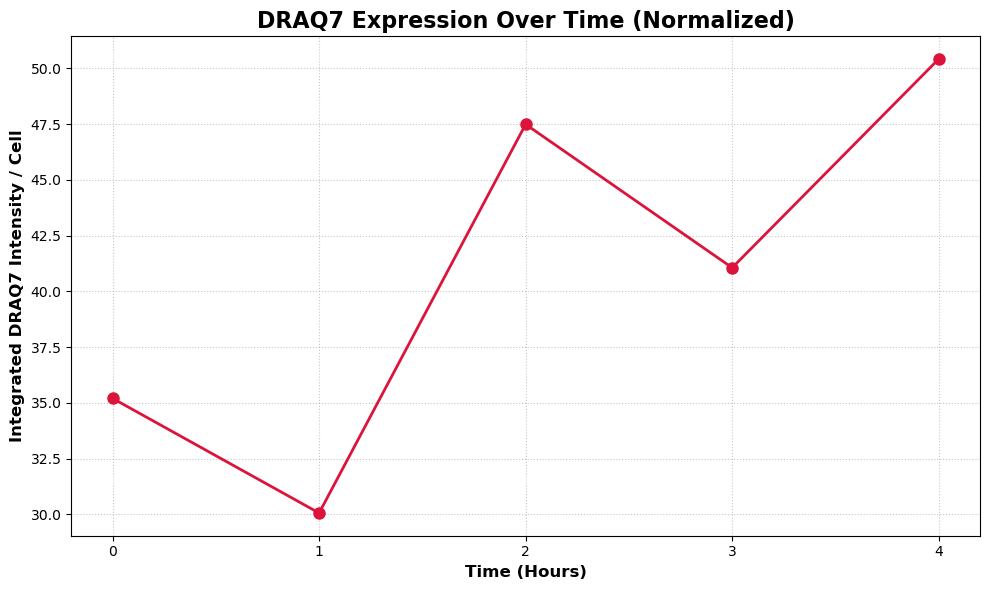

In [13]:

# %matplotlib qt

import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog, simpledialog
import os

def parse_and_integrate_intensity(filepath):
    """
    Parses the text file into separate blocks and calculates the total 
    integrated intensity (Area Under the Curve) across all blocks.
    """
    blocks = []
    current_micron = []
    current_mean = []
    
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                try:
                    m = float(parts[0])
                    v = float(parts[1])
                    current_micron.append(m)
                    current_mean.append(v)
                except ValueError:
                    # This hits when it reads the "[micron] Mean" header
                    if current_micron:
                        blocks.append((current_micron, current_mean))
                        current_micron = []
                        current_mean = []
                        
        # Append the final block if the file ends
        if current_micron:
            blocks.append((current_micron, current_mean))
            
    # Calculate Area Under the Curve for each block to account for varying step sizes
    total_integrated_intensity = 0.0
    for m, v in blocks:
        # np.trapz integrates the 'y' values (Mean) along the 'x' spacing (micron)
        area = np.trapz(v, m)
        total_integrated_intensity += area
        
    return total_integrated_intensity

def main():
    # Hide the main background tkinter window
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("-> Please select your DRAQ7 text files...")
    file_paths = filedialog.askopenfilenames(
        title="Select DRAQ7 Intensity Files",
        filetypes=[("Text Files", "*.txt"), ("All Files", "*.*")]
    )
    
    if not file_paths:
        print("No files selected. Exiting.")
        root.destroy()
        return

    data_points = []

    # Loop through each selected file and prompt the user for input
    for filepath in file_paths:
        filename = os.path.basename(filepath)
        
        # 1. Ask for the Timepoint
        time_val = simpledialog.askfloat(
            "Input Timepoint", 
            f"File: {filename}\n\nEnter the timepoint (e.g., 0, 1, 2, 3, 4):",
            parent=root
        )
        if time_val is None:
            print(f"Skipped {filename}.")
            continue
            
        # 2. Ask for the Cell Count
        cells_val = simpledialog.askinteger(
            "Input Cell Count", 
            f"File: {filename}\nTime: {time_val}h\n\nEnter the number of DRAQ7 expressing cells:",
            parent=root
        )
        if cells_val is None or cells_val <= 0:
            print(f"Invalid cell count for {filename}. Skipped.")
            continue

        # 3. Process the file
        total_intensity = parse_and_integrate_intensity(filepath)
        intensity_per_cell = total_intensity / cells_val
        
        data_points.append({
            'time': time_val,
            'intensity_per_cell': intensity_per_cell
        })
        
        print(f"Processed {filename} -> Time: {time_val}h | Cells: {cells_val} | Intensity/Cell: {intensity_per_cell:.2f}")

    if not data_points:
        print("No valid data points collected.")
        root.destroy()
        return

    # Sort data by time so the line graph draws chronologically from left to right
    data_points.sort(key=lambda x: x['time'])
    
    times = [pt['time'] for pt in data_points]
    intensities = [pt['intensity_per_cell'] for pt in data_points]

    # ==========================================
    # PLOTTING
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    plt.plot(times, intensities, marker='o', markersize=8, color='crimson', linewidth=2, linestyle='-')
    
    plt.title("DRAQ7 Expression Over Time (Normalized)", fontsize=16, fontweight='bold')
    plt.xlabel("Time (Hours)", fontsize=12, fontweight='bold')
    plt.ylabel("Integrated DRAQ7 Intensity / Cell", fontsize=12, fontweight='bold')
    
    # Set x-ticks to strictly match the timepoints provided
    plt.xticks(times)
    
    # Grid for easier reading
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()

    # ==========================================
    # SAVE & DISPLAY
    # ==========================================
    save_path = filedialog.asksaveasfilename(
        title="Save Plot As",
        defaultextension=".png",
        filetypes=[("PNG Image", "*.png"), ("PDF Document", "*.pdf"), ("SVG Graphics", "*.svg"), ("All Files", "*.*")],
        parent=root
    )

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nFigure successfully saved to: {save_path}")
    else:
        print("\nSave cancelled. Displaying figure only.")

    # Destroy the tkinter root before showing the plot to avoid hanging windows
    root.destroy()

    plt.show()

if __name__ == "__main__":
    main()

## Coloc

In [53]:
# %matplotlib inline
# ============================================================
#  BLOCK 7 — Colocalization of DBSCAN clusters with mNeonGreen
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tifffile
import tkinter as tk
from tkinter import filedialog
import os
import re

# ============================================================
# 1. SETTINGS
# ============================================================
OUTPUT_DIR = r"Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Colocalization"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DBSCAN_CHANNEL = 0       # the DBSCAN cluster map
MNEON_CHANNEL  = 1       # the mNeonGreen ground truth

RANK_BY = 'pearson'      
HIGHLIGHT_PARAMS = '10,10,300'   

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8, 'axes.linewidth': 0.6, 'axes.titlesize': 9, 'axes.titleweight': 'bold',
    'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'legend.fontsize': 7, 'legend.frameon': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'savefig.dpi': 300,
})

# ============================================================
# 2. HELPERS
# ============================================================
def load_two_channels(path):
    arr = np.squeeze(tifffile.imread(path))
    if arr.ndim == 2:
        raise ValueError(f"{os.path.basename(path)}: single-channel image — cannot split.")
    if arr.ndim > 3:
        raise ValueError(f"{os.path.basename(path)}: {arr.ndim}D stack — reduce to 2D channels first.")
    ax = int(np.argmin(arr.shape))               
    if arr.shape[ax] > 4:
        raise ValueError(f"{os.path.basename(path)}: no obvious channel axis (shape {arr.shape}).")
    arr = np.moveaxis(arr, ax, 0).astype(float)  
    C = arr.shape[0]
    if max(DBSCAN_CHANNEL, MNEON_CHANNEL) >= C:
        raise ValueError(f"{os.path.basename(path)}: channel index out of range (has {C} channels).")
    return arr[DBSCAN_CHANNEL], arr[MNEON_CHANNEL], arr.shape

def otsu(x):
    x = x[np.isfinite(x)].ravel()
    if x.size == 0 or x.max() == x.min():
        return float(x.min()) if x.size else 0.0
    hist, edges = np.histogram(x, bins=256)
    centers = (edges[:-1] + edges[1:]) / 2
    wb = np.cumsum(hist).astype(float)
    wf = wb[-1] - wb
    csum = np.cumsum(hist * centers)
    mb = csum / np.maximum(wb, 1)
    mf = (csum[-1] - csum) / np.maximum(wf, 1)
    between = wb * wf * (mb - mf) ** 2
    return float(centers[int(np.argmax(between))])

def pearson(a, b):
    a = a.ravel().astype(float); b = b.ravel().astype(float)
    a = a - a.mean(); b = b - b.mean()
    denom = np.sqrt((a * a).sum() * (b * b).sum())
    return float((a * b).sum() / denom) if denom > 0 else np.nan

def coloc_metrics(D, G):
    td, tg = otsu(D), otsu(G)
    maskD, maskG = D > td, G > tg
    union = maskD | maskG
    inter = maskD & maskG
    r_sig = pearson(D[union], G[union]) if union.sum() > 1 else np.nan
    r_all = pearson(D, G)
    M1 = float(D[maskG].sum() / D.sum()) if D.sum() > 0 else np.nan   
    M2 = float(G[maskD].sum() / G.sum()) if G.sum() > 0 else np.nan   
    denom = maskD.sum() + maskG.sum()
    dice = float(2 * inter.sum() / denom) if denom > 0 else np.nan
    iou = float(inter.sum() / union.sum()) if union.sum() > 0 else np.nan
    return {'pearson': r_sig, 'pearson_whole': r_all, 'manders_m1': M1,
            'manders_m2': M2, 'dice': dice, 'iou': iou}

# ============================================================
# 3. LOAD + MEASURE + CUSTOM SORT
# ============================================================
root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
files = filedialog.askopenfilenames(title="Select composite .tif files (one per DBSCAN parameter set)",
                                    filetypes=[("TIFF", "*.tif *.tiff")])
root.destroy()
if not files:
    raise ValueError("No .tif files selected.")

rows = []
for f in files:
    label = os.path.splitext(os.path.basename(f))[0]
    D, G, shape = load_two_channels(f)
    m = coloc_metrics(D, G)
    m['parameters'] = label
    rows.append(m)

def parse_params(name):
    m = re.match(r'\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)', str(name))
    return tuple(int(x) for x in m.groups()) if m else (0, 0, 0)

df = pd.DataFrame(rows).set_index('parameters')
params = {p: parse_params(p) for p in df.index}

# Custom narrative sort based on the baseline
base_r, base_s, base_L = parse_params(HIGHLIGHT_PARAMS)

def custom_sort(p_str):
    r, s, l = params[p_str]
    # 1. Radius Sweep Down
    if r < base_r and s == base_s and l == base_L: return (0, r)
    # 2. Radius Sweep Up
    if r > base_r and s == base_s and l == base_L: return (1, r)
    # 3. Samples Sweep Down
    if r == base_r and s < base_s and l == base_L: return (2, s)
    # 4. BASELINE
    if r == base_r and s == base_s and l == base_L: return (3, 0)
    # 5. Samples Sweep Up
    if r == base_r and s > base_s and l == base_L: return (4, s)
    # 6. Localizations Sweep Down
    if r == base_r and s == base_s and l < base_L: return (5, l)
    # 7. Localizations Sweep Up
    if r == base_r and s == base_s and l > base_L: return (6, l)
    # Fallback for unexpected parameters
    return (7, r, s, l)

order = sorted(df.index, key=custom_sort)
df = df.loc[order] 

df.to_csv(os.path.join(OUTPUT_DIR, "colocalization_metrics_ordered.csv"))
print(f"\nColocalization metrics extracted and ordered structurally.")

# ============================================================
# 4. FIGURE
# ============================================================
RANK_LABELS = {'pearson': "Pearson r (in signal)", 'manders_m1': "Manders M1",
               'manders_m2': "Manders M2", 'dice': "Dice (Mask Overlap)"}
metric_label = RANK_LABELS.get(RANK_BY, RANK_BY)

used = next((p for p in df.index if str(p).startswith(HIGHLIGHT_PARAMS)), None)
def plabel(p):
    r, s, L = params[p]
    return f"{r} nm  ·  {s}  ·  {L}"

fig = plt.figure(figsize=(13, max(3.8, 0.55 * len(df) + 2.2))); fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.28, left=0.27, right=0.97,
                       top=0.80, bottom=0.16, width_ratios=[1.35, 1.0])
fig.suptitle("Colocalization with mNeonGreen across DBSCAN settings",
             fontsize=12.5, fontweight='bold', y=0.97)
fig.text(0.5, 0.895, "DBSCAN parameters:  search radius (nm)  ·  min samples  ·  min localizations",
         ha='center', va='top', fontsize=8, color='#444444')

# --- Panel 1: Bar chart ---
ax = fig.add_subplot(gs[0, 0])
ys = np.arange(len(df))[::-1] 
vals = df[RANK_BY].values.astype(float)
HL, NEUT = '#C44E52', '#cfd8e3'
colors = [HL if p == used else NEUT for p in df.index]

ax.barh(ys, vals, color=colors, edgecolor='black', linewidth=0.5, height=0.62, zorder=3)
for y, v, p in zip(ys, vals, df.index):
    tag = "   ← baseline" if p == used else ""
    ax.text(v + 0.005, y, f"{v:.3f}{tag}", va='center', ha='left', fontsize=7.6,
            color=HL if p == used else 'black', fontweight='bold' if p == used else 'normal')
ax.set_yticks(ys); ax.set_yticklabels([plabel(p) for p in df.index], fontsize=7.6)

for lbl, p in zip(ax.get_yticklabels(), df.index):
    if p == used:
        lbl.set_color(HL); lbl.set_fontweight('bold')
        
ax.set_xlim(0, max(vals) * 1.25)
ax.set_xlabel(metric_label); ax.tick_params(left=False)

# --- Panel 2: Table ---
ax = fig.add_subplot(gs[0, 1]); ax.axis('off')
ax.text(0, 1.0, "All metrics (Symmetrical Parameter Sweeps)", fontweight='bold', fontsize=9.5, va='top')
hdr = f"{'radius·smp·loc':<15}{'Pears':>7}{'M1':>6}{'M2':>6}{'Dice':>6}"
lines = [hdr, ""]
for p in df.index:
    r = df.loc[p]
    mark = ">" if p == used else " "
    lab = "·".join(str(x) for x in params[p])
    lines.append(f"{mark}{lab:<14}{r['pearson']:>7.3f}{r['manders_m1']:>6.2f}"
                 f"{r['manders_m2']:>6.2f}{r['dice']:>6.2f}")
ax.text(0, 0.90, "\n".join(lines), fontsize=7.3, va='top', family='monospace')

fig.text(0.5, 0.04,
         "Pearson = co-distribution in signal.   M1 = DBSCAN signal on mNeonGreen.   "
         "M2 = mNeonGreen captured by clusters.   Dice = Binary mask overlap.   Thresholds: Otsu.",
         ha='center', va='bottom', fontsize=6.4, color='#666666')

for a in fig.axes:
    for sp in ('top', 'right'):
        if sp in a.spines:
            a.spines[sp].set_visible(False)

fig.savefig(os.path.join(OUTPUT_DIR, "colocalization_comparison_ordered.pdf"), dpi=300,
            bbox_inches='tight', facecolor='white')
plt.close(fig)
print(f"Saved colocalization_comparison_ordered.pdf (+ metrics CSV) -> {OUTPUT_DIR}")


Colocalization metrics extracted and ordered structurally.
Saved colocalization_comparison_ordered.pdf (+ metrics CSV) -> Z:\mh\ikom\mycohiv\Richard\FiguresAndDBSCAN\DBSCAN\RBJ2exp1B3\FinalDBSCANS\python\Colocalization
